# Building Blocks Analysis for ChEMBL-100

## Overview

This directory contains a Python script and a Jupyter Notebook designed to analyze and compare the building blocks used by different retrosynthesis search algorithms on a set of 100 molecules from ChEMBL.

The analysis focuses on understanding the diversity, uniqueness, and practical feasibility of the synthesis routes proposed by each algorithm.

---

## Workflow

The process is a two-step workflow. You must complete Step 1 before running Step 2.

### **Step 1: Extract Building Blocks**

⚠️ **IMPORTANT**: You can run this script **FIRST** executing the analysis notebook in case you want to extract the building blocks again (parquet files are provided...).

-   **Script**: `4_extract_building_blocks_nested_list.py`

#### What It Does

This script processes the raw output files (`.hdf`) from AiZynthFinder for five different search algorithms. It extracts the building blocks from all solved synthesis routes for each of the 100 target molecules. The results, which include nested lists of building blocks for each route, are saved into `.parquet` files. This pre-processing step is essential for the analysis notebook.

---

### **Step 2: Analyze and Visualize Results**

-   **Notebook**: `4_building_blocks_chembl100_nested.ipynb`

⚠️ **IMPORTANT**: You need to extract the correct removed building blocks via setting `recalculate_emolecules = True` and run the code once like that.

#### What It Does
This notebook loads the pre-processed `.parquet` files and conducts a comprehensive comparative analysis of the building blocks across the different search algorithms.
#### Key Visualizations:

*   **Comprehensive Boxplot**: A single plot that compares all algorithms across four key metrics: BB Coverage, Unique BBs, Unavailable BBs, and Solvable Routes. It also overlays the analytical and experiment 2 solved molecule rates.
*   **UpSet Plot**: Visualizes the intersections and unions of building block sets between algorithms, showing which combinations provide the best coverage of the chemical space.
*   **Summary Tables**: Provides a clear, quantitative summary of all calculated metrics for easy comparison.

In [1]:
from pathlib import Path

# Get the current directory as a Path object
current_dir = Path.cwd()

# Get the parent directory
repository_directory = current_dir.parent
result_path = str(repository_directory) +   "/data/results/azf/chembl100/"
save_path = str(repository_directory) +  "/results/visualizations"

print(f"Repository Directory:  {repository_directory}")
print(f"Result Path:  {result_path}")
print(f"Save Path:  {save_path}")

Repository Directory:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS
Result Path:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/data/results/azf/chembl100/
Save Path:  /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/visualizations


In [2]:
def find_algorithm(key):
    if "0_chembl100_default_retrostar_0" in key:
        return "Retro*-0"
    elif "1_chembl100_default_mcts" in key:
        return "MCTS"
    elif "2_chembl100_diversity_forcing_mcts" in key:
        return "Distance-MCTS"
    elif "3_chembl100_expansion_clustering_mcts" in key:
        # expansion_clustering_mcts
        return "Cluster-MCTS"
    elif "4_chembl100_expansion_clustering_retrostar_0" in key:
        # expansion_clustering_retrostar
        return "Cluster-Retro*-0"
    else:
        raise ValueError(f"Could not map key {key} to an algorithm")

In [3]:
from pathlib import Path
import pandas as pd

# Get the building_blocks_nested directory
building_blocks_nested_dir = Path(save_path) / "building_blocks_nested"

# Load all parquet files in the building_blocks_nested directory
all_building_blocks = {}

for parquet_file in building_blocks_nested_dir.glob("*_building_blocks.parquet"):
    # Extract the key name (remove _building_blocks.parquet suffix)
    key = find_algorithm(str(parquet_file))
    
    # Load the parquet file (nested lists are preserved automatically)
    df = pd.read_parquet(parquet_file)
    
    # Store in dictionary
    all_building_blocks[key] = df
    
    print(f"Loaded {key}: {len(df)} molecules, {df['num_routes'].sum()} total routes")

# Sort the dictionary by keys of algorithm_order

# Display summary
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total datasets loaded: {len(all_building_blocks)}")
print(f"Available keys: {list(all_building_blocks.keys())}")

all_building_blocks["Retro*-0"]

Loaded Cluster-Retro*-0: 100 molecules, 165443 total routes
Loaded Distance-MCTS: 100 molecules, 243260 total routes
Loaded MCTS: 100 molecules, 272506 total routes
Loaded Cluster-MCTS: 100 molecules, 25819 total routes
Loaded Retro*-0: 100 molecules, 170605 total routes

SUMMARY
Total datasets loaded: 5
Available keys: ['Cluster-Retro*-0', 'Distance-MCTS', 'MCTS', 'Cluster-MCTS', 'Retro*-0']


,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,precursors_availability,policy_used_counts,profiling,cluster_labels,cluster_time,distance_matrix,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,7052.093831,6.928230,6,1006626,15,82,23979,1843,...,emolecules;emolecules;emolecules,{'retrostar_mlp': 158033},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.481905,"[[0.0, 4.056214687790253, 4.587610975118744, 4...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9866...","[[CC(=O)c1ccc(Br)cc1, COc1ccc2cc(B(O)O)sc2c1, ...",1843
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,6331.040757,4.892638,2,942245,16,97,21604,1188,...,emolecules;emolecules;emolecules,{'retrostar_mlp': 121390},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",1.474309,"[[0.0, 0.6413043478260869, 1.5241935483870968,...","{'B': None, 'Br': ['emolecules'], 'BrBr': None...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[c1ccc2c(C3CCNCC3)cccc2c1, NCCCCBr, O=C(O)c1c...",1188
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,6007.997541,13.575945,25,861912,16,79,25035,278,...,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 150756},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.759273,"[[0.0, 1.1733333333333333, 4.186047993125849, ...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[COB(OC)OC, Brc1cc2c[nH]ccc-2n1, OB(O)c1cccc(...",278
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,4327.980053,5.384270,6,825962,15,126,23552,1467,...,emolecules;emolecules;emolecules,{'retrostar_mlp': 172777},"{'expansion_calls': 25000, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, ...",1.799975,"[[0.0, 7.232663702763068, 7.255273521884514, 7...","{'B': None, 'Br': ['emolecules'], 'BrBr': None...","0.9940, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[NC(=O)c1ccc(N(CCCl)CCCl)cc1, CN(C)CCCNC(=O)c...",1467
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5843.571136,4.503498,4,913337,16,77,23749,1244,...,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 142074},"{'expansion_calls': 25000, 'reactants_generati...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, ...",1.421775,"[[0.0, 2.6470238095238097, 5.270012315270936, ...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[[I-], O=C(CBr)NCc1ccccc1, O=C1CCC(=O)N1Cl, O...",1239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,CN1CCN(CCCOc2ccc(N3C(=O)C(=Cc4ccc(Oc5ccc([N+](...,7200.328327,4.433981,2,1317101,17,74,18702,2368,...,emolecules;emolecules;emolecules;emolecules,{'retrostar_mlp': 109125},"{'expansion_calls': 24634, 'reactants_generati...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.378024,"[[0.0, 1.1663615560640732, 3.343751060436391, ...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[CS(=O)(=O)Cl, CN1CCN(CCCO)CC1, O=[N+]([O-])c...",2368
96,96,O=C(OCCCO[N+](=O)[O-])C1OC(Oc2cc3oc(-c4ccc(OCc...,7200.301584,25.472178,37,875958,11,101,25012,94,...,emolecules;emolecules;emolecules;emolecules;em...,{'retrostar_mlp': 110838},"{'expansion_calls': 22423, 'reactants_generati...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.958258,"[[0.0, 2.6403162055335967, 0.8529411764705883,...","{'B': None, 'Br': None, 'BrBr': None, 'BrC(Br)...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[BrCc1ccccc1, O=[N+]([O-])O, OCCCO, OCc1ccccc...",94
97,97,Cn1cc(S(=O)(=O)NCCOc2ccc3c(c2)C(C2(c4ccc(Cl)cc...,5644.714821,6.483392,6,631221,15,61,24930,1

In [4]:
algorithm_order = [
    'MCTS',
    'Distance-MCTS',
    'Cluster-MCTS',
    'Retro*-0',
    'Cluster-Retro*-0'
]

# Sort the dictionary according to algorithm_order
all_building_blocks = {key: all_building_blocks[key] for key in algorithm_order if key in all_building_blocks}

print(f"Sorted dictionary keys: {list(all_building_blocks.keys())}")

Sorted dictionary keys: ['MCTS', 'Distance-MCTS', 'Cluster-MCTS', 'Retro*-0', 'Cluster-Retro*-0']


### building block calculations

Calculate the inchi keys for the building blocks

In [5]:
from rdkit import Chem

def smiles_to_inchi_key(smiles):
    """Convert a single SMILES to InChI key"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToInchiKey(mol)
        else:
            raise ValueError("Invalid SMILES")
    except:
        raise ValueError("Conversion failed")

def nested_smiles_to_inchi_keys(nested_list):
    """Convert nested list of SMILES to nested list of InChI keys"""
    return [[smiles_to_inchi_key(smiles) for smiles in route_bbs] for route_bbs in nested_list]

def get_unique_building_block_sets(list_of_routes):
    """
    Takes a list of routes (where each route is a list of InChI keys)
    and returns a new list containing only the unique sets of building blocks.
    
    Example:
    Input:  [['A','B'], ['A','B','C'], ['B','A'], ['A','B']]
    Output: [['A','B'], ['A','B','C']] 
            (Order of lists in the output doesn't matter)
    """
    
    # This set will store the unique combinations we've seen.
    # We use frozenset because sets are "hashable" and can be
    # added to other sets, unlike lists.
    seen_combinations = set()
    
    # This list will hold our final, unique routes.
    unique_routes_list = []
    
    for route in list_of_routes:
        # 1. Create a frozenset from the route.
        # This ignores order ('B','A' becomes same as 'A','B')
        # and internal duplicates ('A','B','A' becomes same as 'A','B').
        route_as_set = frozenset(route)
        
        # 2. Check if we have already seen this combination.
        if route_as_set not in seen_combinations:
            
            # 3. If not, add it to our 'seen' set.
            seen_combinations.add(route_as_set)
            
            # 4. And add a clean, sorted version of the route
            #    to our final list. We sort it to have a nice,
            #    canonical representation (e.g., always ['A','B'] not ['B','A']).
            unique_routes_list.append(sorted(list(route_as_set)))
            
    return unique_routes_list

# Add InChI key column for nested building blocks only
for key, df in all_building_blocks.items():
    print(f"Processing InChI keys for {key}...")
    
    # Convert nested building blocks to nested InChI keys (preserves route structure)
    df['solved_routes_building_blocks_nested_inchi_keys'] = df['solved_routes_building_blocks_nested'].apply(nested_smiles_to_inchi_keys)
    
    # Count how many InChI keys are valid
    total_bbs = sum(sum(len(route) for route in nested) for nested in df['solved_routes_building_blocks_nested'])
    valid_inchi = sum(sum(sum(1 for ik in route if ik is not None) for route in nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys'])
    
    print(f"  - Total building blocks: {total_bbs}")
    print(f"  - Valid InChI keys: {valid_inchi}")
    
    if total_bbs > valid_inchi:
        print(f"  - Failed conversions: {total_bbs - valid_inchi}")

    # Deduplicate InChI keys within each route list as we are only interested in unique building block combinations used.
    # This means that routes that rely on the same building block but are different in the order will count exactly once.

    df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'] = df['solved_routes_building_blocks_nested_inchi_keys'].apply(get_unique_building_block_sets)
    df['num_routes_deduplicated'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(len)

    # rename the num_routes column to num_routes_original for clarity
    df.rename(columns={'num_routes': 'num_routes_original'}, inplace=True)

    # Statistics: Count total BBs after deduplication
    total_bbs_after_dedup = sum(len(route) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'] for route in nested)
    num_routes_before = sum(len(nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys'])
    num_routes_after = sum(len(nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'])
    
    print(f"  - Routes before deduplication: {num_routes_before}")
    print(f"  - Routes after deduplication: {num_routes_after}")
    print(f"  - Total building blocks in deduplicated routes: {total_bbs_after_dedup}")

all_building_blocks["MCTS"]

Processing InChI keys for MCTS...
  - Total building blocks: 1918636
  - Valid InChI keys: 1918636
  - Routes before deduplication: 272506
  - Routes after deduplication: 205745
  - Total building blocks in deduplicated routes: 1430221
Processing InChI keys for Distance-MCTS...
  - Total building blocks: 1742503
  - Valid InChI keys: 1742503
  - Routes before deduplication: 243260
  - Routes after deduplication: 160934
  - Total building blocks in deduplicated routes: 1118504
Processing InChI keys for Cluster-MCTS...
  - Total building blocks: 204151
  - Valid InChI keys: 204151
  - Routes before deduplication: 25819
  - Routes after deduplication: 15922
  - Total building blocks in deduplicated routes: 123011
Processing InChI keys for Retro*-0...
  - Total building blocks: 1034214
  - Valid InChI keys: 1034214
  - Routes before deduplication: 170605
  - Routes after deduplication: 147765
  - Total building blocks in deduplicated routes: 891736
Processing InChI keys for Cluster-Retro*-

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,cluster_labels,cluster_time,distance_matrix,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes_original,solved_routes_building_blocks_nested_inchi_keys,solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists,num_routes_deduplicated
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,4398.530200,51.957295,1,99371,30,93,96128,4167,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, ...",8.158752,"[[0.0, 0.7681159420289855, 1.68756038647343, 1...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[O=C(Cl)c1ccc(OCCN2CCCCC2)cc1, COc1ccc2cc(B(O...",4167,"[[QGKJLTUHTANSOU-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...","[[JZJWCDQGIPQBAO-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...",3018
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,5352.101914,152.162930,1,151881,30,128,146564,3965,...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, ...",7.106539,"[[0.0, 0.9882352941176471, 2.3777173913043477,...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[NCCCCBr, c1ccc2c(C3CCNCC3)cccc2c1, O=C(Cl)c1...",3895,"[[MVZBYZAIKPPGSW-UHFFFAOYSA-N, SSSBLYQLIOQJSB-...","[[CYIGYCMQCJGBEE-UHFFFAOYSA-N, MVZBYZAIKPPGSW-...",3169
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,7201.377687,1289.084187,19,166860,30,81,158235,879,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.634415,"[[0.0, 0.7586206896551724, 2.805418719211823, ...","{'B': ['emolecules'], 'Br': None, 'BrBr': ['em...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[Brc1cc2c[nH]ccc-2n1, COc1c(Br)cccc1B(O)O, NC...",875,"[[OFCLQVNMLZZZLX-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...","[[FQDDBYGPHUUTRN-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...",745
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,3910.418370,213.444569,10,157003,30,226,152499,1827,...,"[2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, ...",4.482391,"[[0.0, 2.5275, 0.8193979933110368, 2.718400218...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[ClCCNCCCl, O=C(Cl)c1ccc(F)cc1, Cn1cc(N)cc1C(...",1787,"[[TXFLGZOGNOOEFZ-UHFFFAOYSA-N, CZKLEJHVLCMVQR-...","[[CZKLEJHVLCMVQR-UHFFFAOYSA-N, MUEOQEUSJMFYHV-...",1475
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5233.868415,19.376062,1,102277,30,71,98344,3146,...,"[0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, ...",8.125868,"[[0.0, 0.6150978564771669, 3.7340071877807723,...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[NNc1ccc(Br)cc1, O=C1CCC(=O)c2ccc(Cl)cc2N1, O...",3082,"[[NRESDXFFSNBDGP-UHFFFAOYSA-N, BUYMLVMIVKWJSQ-...","[[BUYMLVMIVKWJSQ-UHFFFAOYSA-N, NRESDXFFSNBDGP-...",2297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,CN1CCN(CCCOc2ccc(N3C(=O)C(=Cc4ccc(Oc5ccc([N+](...,3453.919355,15.574428,1,71400,30,82,69136,5437,...,"[1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",8.505986,"[[0.0, 2.526829268292683, 2.466044954567193, 2...","{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[O=Cc1ccc(Oc2ccc([N+](=O)[O-])cc2)cc1, O=C(O)...",5427,"[[OCHOSUFDGPHRJA-UHFFFAOYSA-N, GQECANUIPBFPLA-...","[[AHACBCCMXMDLCU-UHFFFAOYSA-N, GQECANUIPBFPLA-...",4466
96,96,O=C(OCCCO[N+](=O)[O-])C1OC(Oc2cc3oc(-c4ccc(OCc...,7463.489973,0.000000,0,47680,30,184,46286,16,...,"[0, 0, 0, 0, 0, 0, 4, 4, 1, 1, 3, 3, 3, 2, 2, 2]",1.092719,"[[0.0, 0.9263157894736842, 0.9263157894736842,...","{'B': None, 'Br': None, 'BrBr': None, 'BrC(Br)...","0.9560, 0.9560, 0.9560, 0.9560, 0.9560, 0.9560...","[[O=[N+]([O-])O, CC(=O)OCCCO, O=C(O)C1OC(O)C(O...",16,"[[GRYLNZFGIOXLOG-UHFFFAOYSA-N, DOUBAFNWVFAWEC-...","[[AEMOLEFTQBMNLQ-UHFFFAOYSA-N, DOUBAFNWVFAWEC-...",15
97,97,Cn1cc(S(=O)(=O)NCCOc2ccc3c(c2)C(C2(c4ccc(Cl)cc...,6761.8662

Calculate the unique inchi keys for each molecule as we are not interested in the routes

In [6]:
# Flatten and get unique InChI keys per molecule
for key, df in all_building_blocks.items():
    print(f"Processing unique InChI keys for {key}...")
    
    # Flatten the nested InChI keys and get unique values per molecule
    df['unique_building_blocks_inchi_keys'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(
        lambda nested_list: list(set([inchi for route_inchi in nested_list for inchi in route_inchi if inchi is not None]))
    )
    
    # Count the number of unique building blocks per molecule
    df['num_unique_building_blocks'] = df['unique_building_blocks_inchi_keys'].apply(len)
    
    print(f"  - Average unique BBs per molecule: {df['num_unique_building_blocks'].mean():.2f}")
    print(f"  - Min unique BBs: {df['num_unique_building_blocks'].min()}")
    print(f"  - Max unique BBs: {df['num_unique_building_blocks'].max()}")

Processing unique InChI keys for MCTS...
  - Average unique BBs per molecule: 322.71
  - Min unique BBs: 19
  - Max unique BBs: 901
Processing unique InChI keys for Distance-MCTS...
  - Average unique BBs per molecule: 300.34
  - Min unique BBs: 29
  - Max unique BBs: 768
Processing unique InChI keys for Cluster-MCTS...
  - Average unique BBs per molecule: 87.36
  - Min unique BBs: 2
  - Max unique BBs: 208
Processing unique InChI keys for Retro*-0...
  - Average unique BBs per molecule: 225.64
  - Min unique BBs: 15
  - Max unique BBs: 800
Processing unique InChI keys for Cluster-Retro*-0...
  - Average unique BBs per molecule: 173.58
  - Min unique BBs: 2
  - Max unique BBs: 685


### add information based on filtered emolecules stock

In [ ]:
recalculate_emolecules = False
if recalculate_emolecules:

    emolecules_without_retrostar = str(repository_directory) +   "/data/stocks/removed_building_blocks/emolecules_without_retrostar_building_blocks_dpvn_format.csv"
    emolecules_without_retrostar = pd.read_csv(emolecules_without_retrostar)

    # recaculate inchi keys for emolecules without retrostar
    emolecules_without_retrostar['inchi_key_recalculated'] = emolecules_without_retrostar['mol'].apply(smiles_to_inchi_key)
    #print(emolecules_without_retrostar[emolecules_without_retrostar['inchi_key'] != emolecules_without_retrostar['inchi_key_recalculated']])
    #print(emolecules_without_retrostar.equals(emolecules_without_retrostar_loaded))
    emolecules_without_retrostar.to_parquet(save_path + "/building_blocks_nested/emolecules_removed.parquet", index=False)
    emolecules_without_retrostar.to_csv(save_path + "/building_blocks_nested/emolecules_removed.csv", index=False)
    emolecules_without_retrostar

In [7]:
emolecules_without_retrostar_loaded = pd.read_parquet(save_path + "/building_blocks_nested/emolecules_removed.parquet")
emolecules_without_retrostar_loaded

,Unnamed: 0,mol,idx,inchi_key,inchi_key_recalculated
0,0,CC(C)CCC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3CC=C4CC(...,0,OTVRYZXVVMZHHW-FNOPAARDSA-N,OTVRYZXVVMZHHW-FNOPAARDSA-N
1,1,CC(C)CCC[C@@H](C)[C@H]1CCC2C3CC=C4CC(OC(=O)Cl)...,1,QNEPTKZEXBPDLF-AWEQCRHCSA-N,QNEPTKZEXBPDLF-AWEQCRHCSA-N
2,2,CCCCCCCCCCCCCC(=O)OC1CC[C@@]2(C)C(=CCC3C2CC[C@...,2,SJDMTGSQPOFVLR-ZVMQTDSHSA-N,SJDMTGSQPOFVLR-ZVMQTDSHSA-N
3,3,CCCCCCCCC(=O)OC1CC[C@@]2(C)C(=CCC3C2CC[C@@]2(C...,3,WCLNGBQPTVENHV-WYKOVRGBSA-N,WCLNGBQPTVENHV-WYKOVRGBSA-N
4,4,CC12CC(O)C(CC1=O)C2(C)C,4,DJQYBVLXBVJHMU-UHFFFAOYSA-N,DJQYBVLXBVJHMU-UHFFFAOYSA-N
...,...,...,...,...,...
22873167,22876041,O=[N+](O)O,22876041,AOCIUCGLIAMDFY-UHFFFAOYSA-N,AOCIUCGLIAMDFY-UHFFFAOYSA-N
22873168,22876042,C#CC(=CC)CC(=O)CN/N=C\C(C)(C)N,22876042,PKTLJOLAWDSTCT-UHFFFAOYSA-N,PKTLJOLAWDSTCT-PWICCMJVSA-N
22873169,22876043,C=c1[nH]c2c[nH]c1c2C=N,22876043,XLLKWWJFKYEJQW-UHFFFAOYSA-N,XLLKWWJFKYEJQW-UHFFFAOYSA-N
22873170,22876044,CC(F)(F)c1ccc(Br)cc1C=O,22876044,JYZPRGUODWVGKJ-UHFFFAOYSA-N,JYZPRGUODWVGKJ-UHFFFAOYSA-N


In [9]:
# Convert emolecules InChI keys to a set for fast lookup
emolecules_inchi_set = set(emolecules_without_retrostar_loaded['inchi_key_recalculated'].dropna())

print(f"Emolecules stock contains {len(emolecules_inchi_set)} unique InChI keys")

def check_bb_in_emolecules(nested_inchi_list, emolecules_set):
    """
    Check if each building block InChI key is in emolecules stock.
    Returns nested boolean list matching the structure of nested_inchi_list.
    """
    return [[inchi in emolecules_set if inchi is not None else False 
             for inchi in route_inchi] 
            for route_inchi in nested_inchi_list]

# Add column checking if building blocks are in emolecules stock
for key, df in all_building_blocks.items():
    print(f"\nProcessing emolecules check for {key}...")
    
    # Create nested boolean list
    df['bb_in_emolecules_nested'] = df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'].apply(
        lambda nested_list: check_bb_in_emolecules(nested_list, emolecules_inchi_set)
    )
    
    # Calculate statistics
    total_bbs = sum(sum(len(route) for route in nested) for nested in df['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'])
    bbs_in_emolecules = sum(sum(sum(1 for is_in_stock in route if is_in_stock) for route in nested) for nested in df['bb_in_emolecules_nested'])
    
    percentage_in_stock = (bbs_in_emolecules / total_bbs * 100) if total_bbs > 0 else 0
    
    print(f"  - Total building blocks: {total_bbs}")
    print(f"  - In emolecules stock: {bbs_in_emolecules} ({percentage_in_stock:.2f}%)")
    print(f"  - NOT in emolecules stock: {total_bbs - bbs_in_emolecules} ({100 - percentage_in_stock:.2f}%)")

print(f"\n{'='*80}")
print("DONE - Emolecules check added")
print(f"{'='*80}")

# Show example
first_key = list(all_building_blocks.keys())[0]
example_df = all_building_blocks[first_key]
print(f"\nFirst molecule example:")
print(f"  - Routes: {example_df.iloc[0]['num_routes_deduplicated']}")
print(f"\n  First route:")
print(f"    InChI keys: {example_df.iloc[0]['solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists'][0][:3]}")
print(f"    In emolecules: {example_df.iloc[0]['bb_in_emolecules_nested'][0][:3]}")

# Display the updated dataframe
all_building_blocks[first_key].head()

Emolecules stock contains 22873172 unique InChI keys

Processing emolecules check for MCTS...
  - Total building blocks: 1430221
  - In emolecules stock: 527293 (36.87%)
  - NOT in emolecules stock: 902928 (63.13%)

Processing emolecules check for Distance-MCTS...
  - Total building blocks: 1118504
  - In emolecules stock: 411552 (36.79%)
  - NOT in emolecules stock: 706952 (63.21%)

Processing emolecules check for Cluster-MCTS...
  - Total building blocks: 123011
  - In emolecules stock: 42395 (34.46%)
  - NOT in emolecules stock: 80616 (65.54%)

Processing emolecules check for Retro*-0...
  - Total building blocks: 891736
  - In emolecules stock: 363663 (40.78%)
  - NOT in emolecules stock: 528073 (59.22%)

Processing emolecules check for Cluster-Retro*-0...
  - Total building blocks: 897136
  - In emolecules stock: 300846 (33.53%)
  - NOT in emolecules stock: 596290 (66.47%)

DONE - Emolecules check added

First molecule example:
  - Routes: 3018

  First route:
    InChI keys: ['JZ

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,stock_info,top_scores,solved_routes_building_blocks_nested,num_routes_original,solved_routes_building_blocks_nested_inchi_keys,solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists,num_routes_deduplicated,unique_building_blocks_inchi_keys,num_unique_building_blocks,bb_in_emolecules_nested
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,4398.530200,51.957295,1,99371,30,93,96128,4167,...,"{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[O=C(Cl)c1ccc(OCCN2CCCCC2)cc1, COc1ccc2cc(B(O...",4167,"[[QGKJLTUHTANSOU-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...","[[JZJWCDQGIPQBAO-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...",3018,"[GRYLNZFGIOXLOG-UHFFFAOYSA-N, GQHTUMJGOHRCHB-U...",459,"[[True, True, False], [True, False, False], [F..."
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,5352.101914,152.162930,1,151881,30,128,146564,3965,...,"{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[NCCCCBr, c1ccc2c(C3CCNCC3)cccc2c1, O=C(Cl)c1...",3895,"[[MVZBYZAIKPPGSW-UHFFFAOYSA-N, SSSBLYQLIOQJSB-...","[[CYIGYCMQCJGBEE-UHFFFAOYSA-N, MVZBYZAIKPPGSW-...",3169,"[ZYBZDDMAAQTLEV-UHFFFAOYSA-N, GQHTUMJGOHRCHB-U...",582,"[[False, False, False], [False, True, False], ..."
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,7201.377687,1289.084187,19,166860,30,81,158235,879,...,"{'B': ['emolecules'], 'Br': None, 'BrBr': ['em...","0.9866, 0.9866, 0.9866, 0.9866, 0.9866, 0.9866...","[[Brc1cc2c[nH]ccc-2n1, COc1c(Br)cccc1B(O)O, NC...",875,"[[OFCLQVNMLZZZLX-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...","[[FQDDBYGPHUUTRN-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...",745,"[PFKFTWBEEFSNDU-UHFFFAOYSA-N, GRYLNZFGIOXLOG-U...",243,"[[False, True, False, True], [True, False, Tru..."
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,3910.418370,213.444569,10,157003,30,226,152499,1827,...,"{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[ClCCNCCCl, O=C(Cl)c1ccc(F)cc1, Cn1cc(N)cc1C(...",1787,"[[TXFLGZOGNOOEFZ-UHFFFAOYSA-N, CZKLEJHVLCMVQR-...","[[CZKLEJHVLCMVQR-UHFFFAOYSA-N, MUEOQEUSJMFYHV-...",1475,"[PFKFTWBEEFSNDU-UHFFFAOYSA-N, QAOWNCQODCNURD-U...",290,"[[False, False, True, False], [False, False, T..."
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5233.868415,19.376062,1,102277,30,71,98344,3146,...,"{'B': None, 'Br': ['emolecules'], 'BrBr': ['em...","0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[[NNc1ccc(Br)cc1, O=C1CCC(=O)c2ccc(Cl)cc2N1, O...",3082,"[[NRESDXFFSNBDGP-UHFFFAOYSA-N, BUYMLVMIVKWJSQ-...","[[BUYMLVMIVKWJSQ-UHFFFAOYSA-N, NRESDXFFSNBDGP-...",2297,"[NCFYOXOXFKGQSL-UHFFFAOYSA-N, GRYLNZFGIOXLOG-U...",427,"[[False, False, True], [False, False, True], [..."


In [10]:
# Add columns for unique building blocks availability in emolecules
for key, df in all_building_blocks.items():
    print(f"\nProcessing unique BB emolecules check for {key}...")
    
    # Check if each unique building block InChI key is in emolecules stock
    df['bb_in_emolecules_unique_building_blocks_inchi_keys'] = df['unique_building_blocks_inchi_keys'].apply(
        lambda inchi_list: [inchi in emolecules_inchi_set for inchi in inchi_list]
    )
    
    # Count how many unique building blocks are in emolecules stock
    df['num_solved_unique_building_blocks'] = df['bb_in_emolecules_unique_building_blocks_inchi_keys'].apply(
        lambda bool_list: sum(bool_list)
    )
    
    # Calculate statistics
    total_unique_bbs = df['num_unique_building_blocks'].sum()
    solved_unique_bbs = df['num_solved_unique_building_blocks'].sum()
    percentage_solved = (solved_unique_bbs / total_unique_bbs * 100) if total_unique_bbs > 0 else 0
    
    print(f"  - Total unique building blocks: {total_unique_bbs}")
    print(f"  - In emolecules stock: {solved_unique_bbs} ({percentage_solved:.2f}%)")
    print(f"  - NOT in emolecules stock: {total_unique_bbs - solved_unique_bbs} ({100 - percentage_solved:.2f}%)")

print(f"\n{'='*80}")
print("DONE - Unique BB emolecules check added")
print(f"{'='*80}")

# Show example
first_key = list(all_building_blocks.keys())[0]
example_df = all_building_blocks[first_key]
print(f"\nFirst molecule example:")
print(f"  - Unique building blocks: {example_df.iloc[0]['num_unique_building_blocks']}")
print(f"  - Unique BBs in emolecules: {example_df.iloc[0]['num_solved_unique_building_blocks']}")
print(f"  - First 3 unique InChI keys: {example_df.iloc[0]['unique_building_blocks_inchi_keys'][:3]}")
print(f"  - Availability: {example_df.iloc[0]['bb_in_emolecules_unique_building_blocks_inchi_keys'][:3]}")

# Display the updated dataframe
all_building_blocks[first_key].head()


Processing unique BB emolecules check for MCTS...
  - Total unique building blocks: 32271
  - In emolecules stock: 21887 (67.82%)
  - NOT in emolecules stock: 10384 (32.18%)

Processing unique BB emolecules check for Distance-MCTS...
  - Total unique building blocks: 30034
  - In emolecules stock: 20283 (67.53%)
  - NOT in emolecules stock: 9751 (32.47%)

Processing unique BB emolecules check for Cluster-MCTS...
  - Total unique building blocks: 8736
  - In emolecules stock: 4871 (55.76%)
  - NOT in emolecules stock: 3865 (44.24%)

Processing unique BB emolecules check for Retro*-0...
  - Total unique building blocks: 22564
  - In emolecules stock: 14953 (66.27%)
  - NOT in emolecules stock: 7611 (33.73%)

Processing unique BB emolecules check for Cluster-Retro*-0...
  - Total unique building blocks: 17358
  - In emolecules stock: 11518 (66.36%)
  - NOT in emolecules stock: 5840 (33.64%)

DONE - Unique BB emolecules check added

First molecule example:
  - Unique building blocks: 459


,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,solved_routes_building_blocks_nested,num_routes_original,solved_routes_building_blocks_nested_inchi_keys,solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists,num_routes_deduplicated,unique_building_blocks_inchi_keys,num_unique_building_blocks,bb_in_emolecules_nested,bb_in_emolecules_unique_building_blocks_inchi_keys,num_solved_unique_building_blocks
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,4398.530200,51.957295,1,99371,30,93,96128,4167,...,"[[O=C(Cl)c1ccc(OCCN2CCCCC2)cc1, COc1ccc2cc(B(O...",4167,"[[QGKJLTUHTANSOU-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...","[[JZJWCDQGIPQBAO-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...",3018,"[GRYLNZFGIOXLOG-UHFFFAOYSA-N, GQHTUMJGOHRCHB-U...",459,"[[True, True, False], [True, False, False], [F...","[False, False, False, True, True, True, True, ...",303
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,5352.101914,152.162930,1,151881,30,128,146564,3965,...,"[[NCCCCBr, c1ccc2c(C3CCNCC3)cccc2c1, O=C(Cl)c1...",3895,"[[MVZBYZAIKPPGSW-UHFFFAOYSA-N, SSSBLYQLIOQJSB-...","[[CYIGYCMQCJGBEE-UHFFFAOYSA-N, MVZBYZAIKPPGSW-...",3169,"[ZYBZDDMAAQTLEV-UHFFFAOYSA-N, GQHTUMJGOHRCHB-U...",582,"[[False, False, False], [False, True, False], ...","[True, False, False, True, True, True, False, ...",424
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,7201.377687,1289.084187,19,166860,30,81,158235,879,...,"[[Brc1cc2c[nH]ccc-2n1, COc1c(Br)cccc1B(O)O, NC...",875,"[[OFCLQVNMLZZZLX-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...","[[FQDDBYGPHUUTRN-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...",745,"[PFKFTWBEEFSNDU-UHFFFAOYSA-N, GRYLNZFGIOXLOG-U...",243,"[[False, True, False, True], [True, False, Tru...","[False, False, False, True, True, True, True, ...",170
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,3910.418370,213.444569,10,157003,30,226,152499,1827,...,"[[ClCCNCCCl, O=C(Cl)c1ccc(F)cc1, Cn1cc(N)cc1C(...",1787,"[[TXFLGZOGNOOEFZ-UHFFFAOYSA-N, CZKLEJHVLCMVQR-...","[[CZKLEJHVLCMVQR-UHFFFAOYSA-N, MUEOQEUSJMFYHV-...",1475,"[PFKFTWBEEFSNDU-UHFFFAOYSA-N, QAOWNCQODCNURD-U...",290,"[[False, False, True, False], [False, False, T...","[False, False, True, False, True, True, True, ...",182
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5233.868415,19.376062,1,102277,30,71,98344,3146,...,"[[NNc1ccc(Br)cc1, O=C1CCC(=O)c2ccc(Cl)cc2N1, O...",3082,"[[NRESDXFFSNBDGP-UHFFFAOYSA-N, BUYMLVMIVKWJSQ-...","[[BUYMLVMIVKWJSQ-UHFFFAOYSA-N, NRESDXFFSNBDGP-...",2297,"[NCFYOXOXFKGQSL-UHFFFAOYSA-N, GRYLNZFGIOXLOG-U...",427,"[[False, False, True], [False, False, True], [...","[True, False, False, True, True, False, True, ...",288


In [11]:
def count_solved_unsolved_routes(bb_in_emolecules_nested):
    """
    Count the number of solved (all True) and unsolved (any False) routes.
    
    Args:
        bb_in_emolecules_nested: Nested boolean list
    
    Returns:
        tuple: (num_solved_routes, num_unsolved_routes)
    """
    num_solved = 0
    num_unsolved = 0
    
    for route_bools in bb_in_emolecules_nested:
        if len(route_bools) == 0:
            # Empty route - consider unsolved
            raise ValueError("Encountered an empty route in bb_in_emolecules_nested.")
        elif all(route_bools):
            # All building blocks are in stock - solved
            num_solved += 1
        else:
            # At least one building block is not in stock - unsolved
            num_unsolved += 1
    
    return num_solved, num_unsolved

# Add columns for solved/unsolved routes and molecule solved status
for key, df in all_building_blocks.items():
    print(f"\nProcessing route status for {key}...")
    
    # Calculate number of solved and unsolved routes
    route_counts = df['bb_in_emolecules_nested'].apply(count_solved_unsolved_routes)
    df['num_solved_routes'] = route_counts.apply(lambda x: x[0])
    df['num_unsolved_routes'] = route_counts.apply(lambda x: x[1])
    
    # Molecule is solved if there is at least one solved route
    df['bb_molecule_solved'] = df['num_solved_routes'] > 0
    
    # Calculate statistics
    total_molecules = len(df)
    molecules_solved = df['bb_molecule_solved'].sum()
    molecules_unsolved = total_molecules - molecules_solved
    
    total_routes = df['num_routes_deduplicated'].sum()
    solved_routes = df['num_solved_routes'].sum()
    unsolved_routes = df['num_unsolved_routes'].sum()
    
    print(f"  Molecules:")
    print(f"    - Total: {total_molecules}")
    print(f"    - Solved: {molecules_solved} ({molecules_solved/total_molecules*100:.2f}%)")
    print(f"    - Unsolved: {molecules_unsolved} ({molecules_unsolved/total_molecules*100:.2f}%)")
    print(f"  Routes:")
    print(f"    - Total: {total_routes}")
    print(f"    - Solved: {solved_routes} ({solved_routes/total_routes*100:.2f}%)")
    print(f"    - Unsolved: {unsolved_routes} ({unsolved_routes/total_routes*100:.2f}%)")

print(f"\n{'='*80}")
print("DONE - Route status columns added")
print(f"{'='*80}")

# Show example
first_key = list(all_building_blocks.keys())[0]
example_df = all_building_blocks[first_key]
print(f"\nFirst molecule example:")
print(f"  - Total routes: {example_df.iloc[0]['num_routes_deduplicated']}")
print(f"  - Solved routes: {example_df.iloc[0]['num_solved_routes']}")
print(f"  - Unsolved routes: {example_df.iloc[0]['num_unsolved_routes']}")
print(f"  - Molecule solved: {example_df.iloc[0]['bb_molecule_solved']}")

# Show a few examples of the route status
print(f"\nRoute status breakdown (first 3 molecules):")
for i in range(min(3, len(example_df))):
    print(f"\nMolecule {i}:")
    print(f"  Routes: {example_df.iloc[i]['num_routes_deduplicated']} total, {example_df.iloc[i]['num_solved_routes']} solved, {example_df.iloc[i]['num_unsolved_routes']} unsolved")
    print(f"  First route BB availability: {example_df.iloc[i]['bb_in_emolecules_nested'][0]}")
    print(f"  Molecule solved: {example_df.iloc[i]['bb_molecule_solved']}")

# Display the updated dataframe
all_building_blocks[first_key].head()


Processing route status for MCTS...
  Molecules:
    - Total: 100
    - Solved: 49 (49.00%)
    - Unsolved: 51 (51.00%)
  Routes:
    - Total: 205745
    - Solved: 3790 (1.84%)
    - Unsolved: 201955 (98.16%)

Processing route status for Distance-MCTS...
  Molecules:
    - Total: 100
    - Solved: 49 (49.00%)
    - Unsolved: 51 (51.00%)
  Routes:
    - Total: 160934
    - Solved: 3160 (1.96%)
    - Unsolved: 157774 (98.04%)

Processing route status for Cluster-MCTS...
  Molecules:
    - Total: 100
    - Solved: 17 (17.00%)
    - Unsolved: 83 (83.00%)
  Routes:
    - Total: 15922
    - Solved: 108 (0.68%)
    - Unsolved: 15814 (99.32%)

Processing route status for Retro*-0...
  Molecules:
    - Total: 100
    - Solved: 47 (47.00%)
    - Unsolved: 53 (53.00%)
  Routes:
    - Total: 147765
    - Solved: 2989 (2.02%)
    - Unsolved: 144776 (97.98%)

Processing route status for Cluster-Retro*-0...
  Molecules:
    - Total: 100
    - Solved: 11 (11.00%)
    - Unsolved: 89 (89.00%)
  Routes:

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,solved_routes_building_blocks_nested_inchi_keys_deduplicated_lists,num_routes_deduplicated,unique_building_blocks_inchi_keys,num_unique_building_blocks,bb_in_emolecules_nested,bb_in_emolecules_unique_building_blocks_inchi_keys,num_solved_unique_building_blocks,num_solved_routes,num_unsolved_routes,bb_molecule_solved
0,0,CC(=O)c1ccc(-c2sc3cc(O)ccc3c2C(=O)c2ccc(OCCN3C...,4398.530200,51.957295,1,99371,30,93,96128,4167,...,"[[JZJWCDQGIPQBAO-UHFFFAOYSA-N, PNRDOYJXKKKYSU-...",3018,"[GRYLNZFGIOXLOG-UHFFFAOYSA-N, GQHTUMJGOHRCHB-U...",459,"[[True, True, False], [True, False, False], [F...","[False, False, False, True, True, True, True, ...",303,19,2999,True
1,1,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,5352.101914,152.162930,1,151881,30,128,146564,3965,...,"[[CYIGYCMQCJGBEE-UHFFFAOYSA-N, MVZBYZAIKPPGSW-...",3169,"[ZYBZDDMAAQTLEV-UHFFFAOYSA-N, GQHTUMJGOHRCHB-U...",582,"[[False, False, False], [False, True, False], ...","[True, False, False, True, True, True, False, ...",424,155,3014,True
2,2,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,7201.377687,1289.084187,19,166860,30,81,158235,879,...,"[[FQDDBYGPHUUTRN-UHFFFAOYSA-N, KSYYRNDZOSXTFU-...",745,"[PFKFTWBEEFSNDU-UHFFFAOYSA-N, GRYLNZFGIOXLOG-U...",243,"[[False, True, False, True], [True, False, Tru...","[False, False, False, True, True, True, True, ...",170,0,745,False
3,3,CN(C)CCCNC(=O)c1cc(NC(=O)c2cc(NC(=O)c3ccc(N(CC...,3910.418370,213.444569,10,157003,30,226,152499,1827,...,"[[CZKLEJHVLCMVQR-UHFFFAOYSA-N, MUEOQEUSJMFYHV-...",1475,"[PFKFTWBEEFSNDU-UHFFFAOYSA-N, QAOWNCQODCNURD-U...",290,"[[False, False, True, False], [False, False, T...","[False, False, True, False, True, True, True, ...",182,27,1448,True
4,4,O=C(CN1C(=O)Cc2c([nH]c3ccc(Br)cc23)-c2ccc(Cl)c...,5233.868415,19.376062,1,102277,30,71,98344,3146,...,"[[BUYMLVMIVKWJSQ-UHFFFAOYSA-N, NRESDXFFSNBDGP-...",2297,"[NCFYOXOXFKGQSL-UHFFFAOYSA-N, GRYLNZFGIOXLOG-U...",427,"[[False, False, True], [False, False, True], [...","[True, False, False, True, True, False, True, ...",288,0,2297,False


## visualizations

Analyzing 5 methods across 100 molecules
Methods: ['MCTS', 'Distance-MCTS', 'Cluster-MCTS', 'Retro*-0', 'Cluster-Retro*-0']

Processing molecules...
  Processing molecule 0/100
  Processing molecule 10/100
  Processing molecule 20/100
  Processing molecule 30/100
  Processing molecule 40/100
  Processing molecule 50/100
  Processing molecule 60/100
  Processing molecule 70/100
  Processing molecule 80/100
  Processing molecule 90/100
Processing complete!



/var/folders/3g/q5h5qc217j52n3jsx0t9w7ym0000gn/T/ipykernel_4427/4134319949.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(coverage_plot_data, labels=short_methods, patch_artist=True,
/var/folders/3g/q5h5qc217j52n3jsx0t9w7ym0000gn/T/ipykernel_4427/4134319949.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(unique_rate_plot_data, labels=short_methods, patch_artist=True,


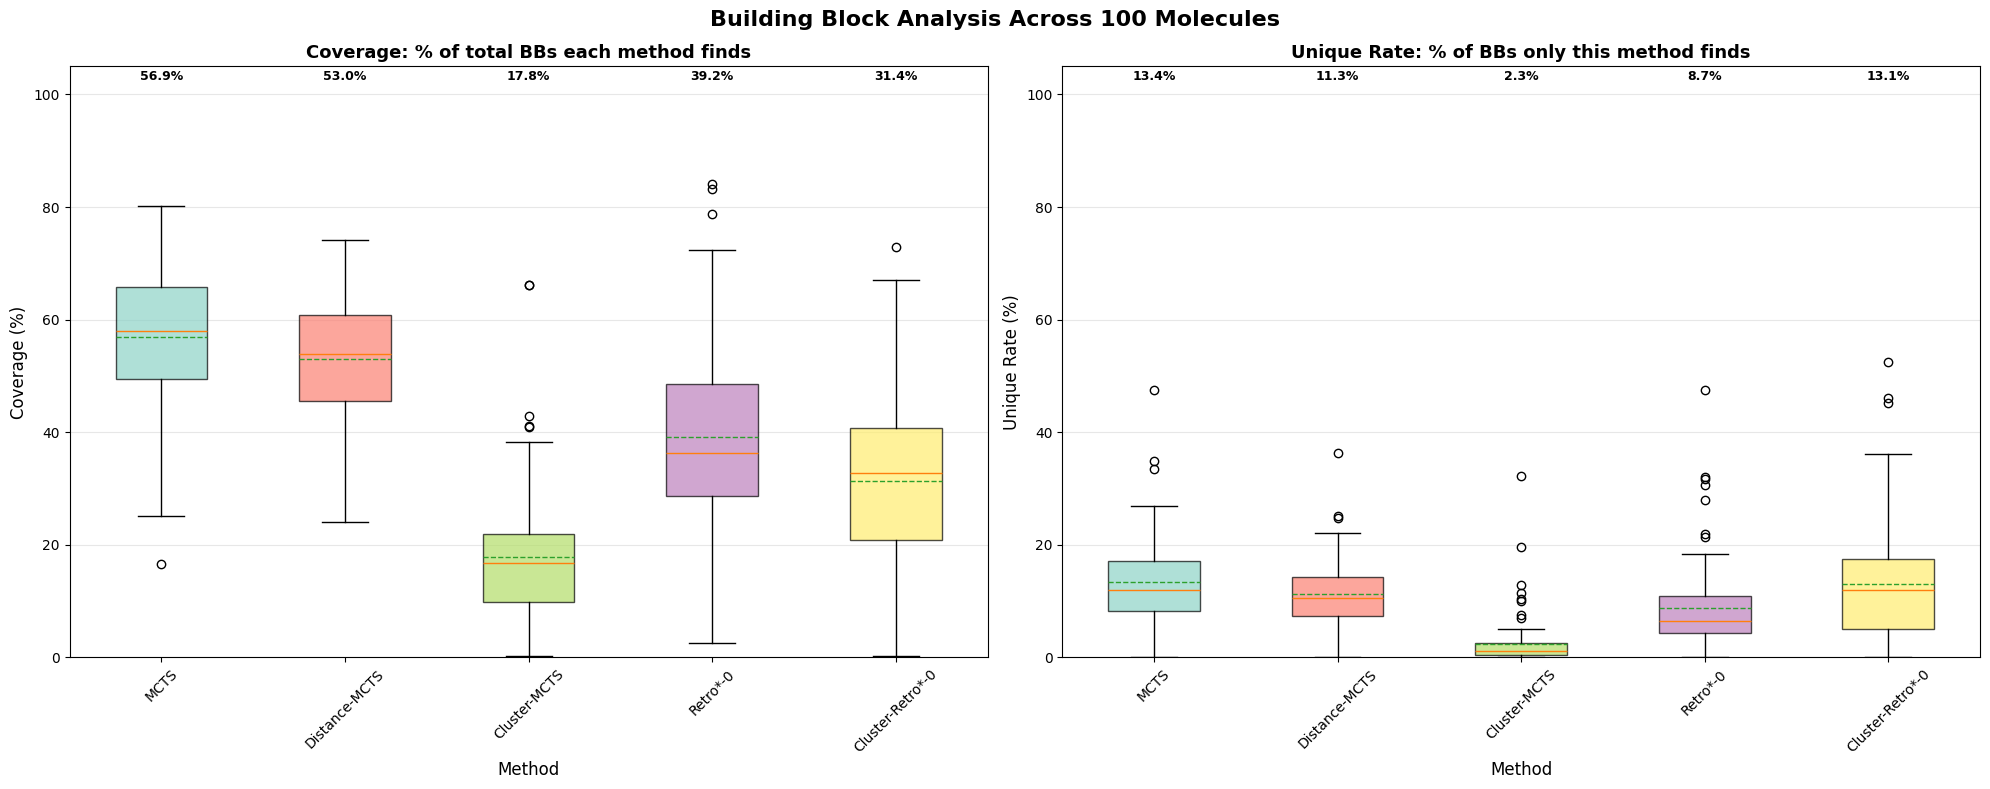


SUMMARY: COVERAGE (How much of the solution space each method covers)

MCTS:
  Mean:   56.94% (average coverage across all molecules)
  Median: 58.03%
  Range:  16.52% - 80.20%

Distance-MCTS:
  Mean:   53.02% (average coverage across all molecules)
  Median: 53.96%
  Range:  24.14% - 74.10%

Cluster-MCTS:
  Mean:   17.85% (average coverage across all molecules)
  Median: 16.86%
  Range:  0.32% - 66.09%

Retro*-0:
  Mean:   39.19% (average coverage across all molecules)
  Median: 36.26%
  Range:  2.58% - 84.09%

Cluster-Retro*-0:
  Mean:   31.40% (average coverage across all molecules)
  Median: 32.83%
  Range:  0.32% - 72.92%

SUMMARY: UNIQUE RATE (How much unique BBs each method contributes)

MCTS:
  Mean:   13.41% (average unique contribution)
  Median: 11.94%
  Range:  0.00% - 47.52%

Distance-MCTS:
  Mean:   11.34% (average unique contribution)
  Median: 10.47%
  Range:  0.00% - 36.36%

Cluster-MCTS:
  Mean:   2.34% (average unique contribution)
  Median: 1.11%
  Range:  0.00% - 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ==============================================================================
# STEP 1: Setup - Get all methods and molecules
# ==============================================================================

def extract_first_digit(method_name):
    """Extract the first digit from method name for sorting"""
    match = re.search(r'\d+', method_name)
    return int(match.group()) if match else 0

# Get all methods (algorithms) sorted by number
methods = list(all_building_blocks.keys())
n_methods = len(methods)

# Create shorter names for plotting
short_methods = methods

# Get all unique molecules (targets)
first_key = methods[0]
all_targets = all_building_blocks[first_key]['target'].unique()
n_molecules = len(all_targets)

print(f"Analyzing {n_methods} methods across {n_molecules} molecules")
print(f"Methods: {methods}\n")

# ==============================================================================
# STEP 2: For each molecule, calculate metrics for each method
# ==============================================================================

# Storage for results
coverage_data = {method: [] for method in methods}
unique_rate_data = {method: [] for method in methods}

print("Processing molecules...")

# Loop through each molecule
for mol_idx, target in enumerate(all_targets):
    if mol_idx % 10 == 0:
        print(f"  Processing molecule {mol_idx}/{n_molecules}")
    
    # --- 2a: Collect building blocks for this molecule from ALL methods ---
    molecule_bbs = {}  # Will store {method: set of InChI keys}
    
    for method in methods:
        df = all_building_blocks[method]
        molecule_row = df[df['target'] == target]
        
        if len(molecule_row) > 0:
            # Get the unique building blocks this method found for this molecule
            inchi_keys = molecule_row.iloc[0]['unique_building_blocks_inchi_keys']
            molecule_bbs[method] = set(inchi_keys)
        else:
            # There must be a molecule row
            raise ValueError(f"Molecule {target} not found in method {method} dataframe")   
    
    # --- 2b: Get the "universal set" - all BBs found by ANY method for this molecule ---
    all_bbs_for_molecule = set()
    for bbs in molecule_bbs.values():
        all_bbs_for_molecule.update(bbs)
    
    # Skip molecules with no building blocks
    if len(all_bbs_for_molecule) == 0:
        raise ValueError(f"Molecule {target} has no building blocks found by any method")
    
    # --- 2c: Calculate metrics for each method ---
    for method in methods:
        method_bbs = molecule_bbs[method]
        
        # COVERAGE: What % of all possible BBs did this method find?
        # Example: If all methods together found 10 unique BBs, and this method found 7,
        #          coverage = 70%
        coverage_pct = (len(method_bbs) / len(all_bbs_for_molecule)) * 100
        coverage_data[method].append(coverage_pct)
        
        # UNIQUE RATE: What % of all possible BBs are ONLY found by this method?
        # Example: If this method found 3 BBs that no other method found,
        #          and total BBs = 10, unique_rate = 30%
        unique_bbs = method_bbs.copy()
        for other_method in methods:
            if other_method != method:
                unique_bbs -= molecule_bbs[other_method]  # Remove BBs found by others
        
        unique_rate_pct = (len(unique_bbs) / len(all_bbs_for_molecule)) * 100
        unique_rate_data[method].append(unique_rate_pct)

print("Processing complete!\n")

# ==============================================================================
# STEP 3: Create boxplots
# ==============================================================================

# Prepare data: list of lists, one list per method
coverage_plot_data = [coverage_data[method] for method in methods]
unique_rate_plot_data = [unique_rate_data[method] for method in methods]

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f'Building Block Analysis Across {n_molecules} Molecules', 
             fontsize=16, fontweight='bold')

# --- LEFT PLOT: Coverage ---
bp1 = axes[0].boxplot(coverage_plot_data, labels=short_methods, patch_artist=True,
                      showmeans=True, meanline=True)

# Add colors
colors = plt.cm.Set3(np.linspace(0, 1, n_methods))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xlabel('Method', fontsize=12)
axes[0].set_ylabel('Coverage (%)', fontsize=12)
axes[0].set_title('Coverage: % of total BBs each method finds', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 105)

# Add mean values above boxes
for i, method in enumerate(methods):
    mean_val = np.mean(coverage_data[method])
    axes[0].text(i + 1, 102, f'{mean_val:.1f}%', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- RIGHT PLOT: Unique Rate ---
bp2 = axes[1].boxplot(unique_rate_plot_data, labels=short_methods, patch_artist=True,
                      showmeans=True, meanline=True)

for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('Method', fontsize=12)
axes[1].set_ylabel('Unique Rate (%)', fontsize=12)
axes[1].set_title('Unique Rate: % of BBs only this method finds', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 105)

# Add mean values above boxes
for i, method in enumerate(methods):
    mean_val = np.mean(unique_rate_data[method])
    axes[1].text(i + 1, 102, f'{mean_val:.1f}%', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
#plt.savefig(f"{save_path}/building_blocks_coverage_unique_rate_boxplot.png",             dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# STEP 4: Print summary statistics
# ==============================================================================

print("\n" + "="*80)
print("SUMMARY: COVERAGE (How much of the solution space each method covers)")
print("="*80)
for method, short_name in zip(methods, short_methods):
    data = coverage_data[method]
    print(f"\n{short_name}:")
    print(f"  Mean:   {np.mean(data):.2f}% (average coverage across all molecules)")
    print(f"  Median: {np.median(data):.2f}%")
    print(f"  Range:  {np.min(data):.2f}% - {np.max(data):.2f}%")

print("\n" + "="*80)
print("SUMMARY: UNIQUE RATE (How much unique BBs each method contributes)")
print("="*80)
for method, short_name in zip(methods, short_methods):
    data = unique_rate_data[method]
    print(f"\n{short_name}:")
    print(f"  Mean:   {np.mean(data):.2f}% (average unique contribution)")
    print(f"  Median: {np.median(data):.2f}%")
    print(f"  Range:  {np.min(data):.2f}% - {np.max(data):.2f}%")

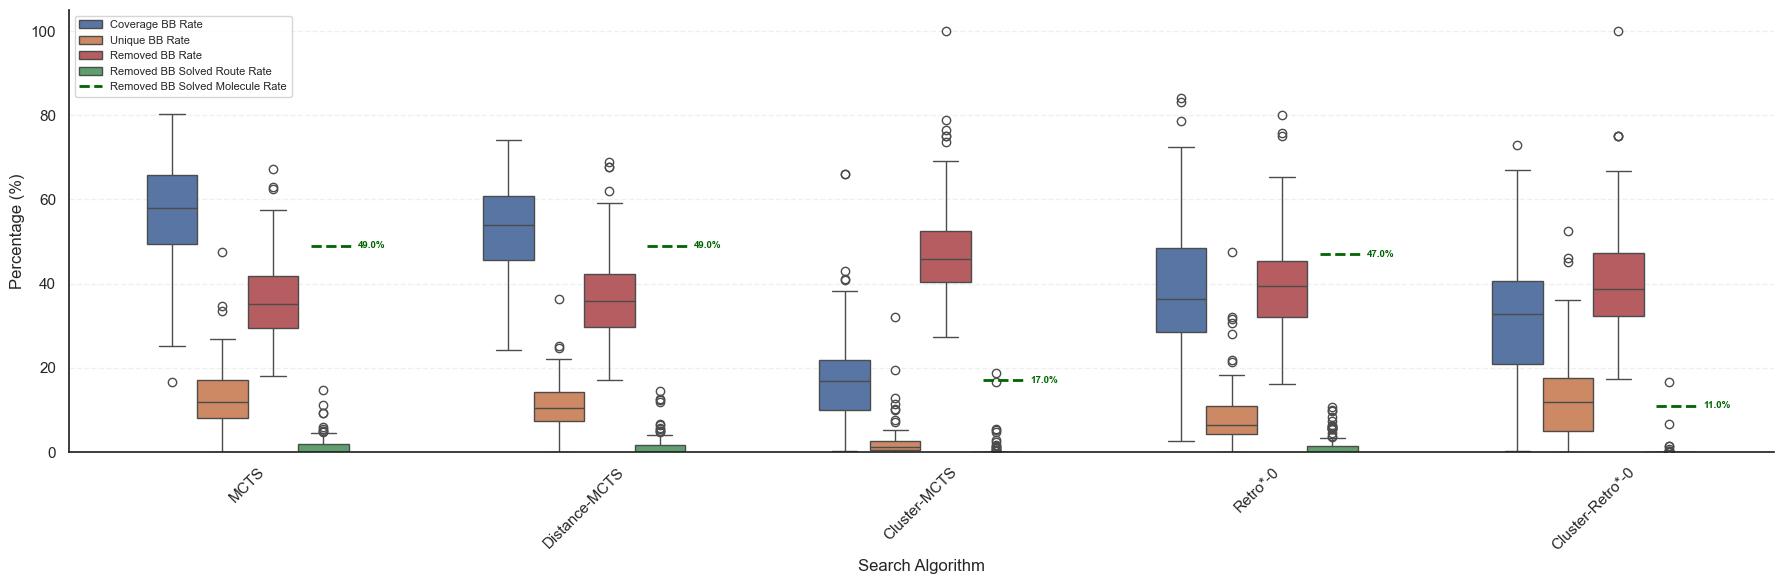


COMPREHENSIVE SUMMARY TABLE
Method               Coverage     Unique Rate  Removed BB   Solved Route Overall Solved
--------------------------------------------------------------------------------
MCTS                  56.94%       13.41%       36.22%         1.36%         49.00%
Distance-MCTS         53.02%       11.34%       37.02%         1.49%         49.00%
Cluster-MCTS          17.85%        2.34%       47.47%         0.64%         17.00%
Retro*-0              39.19%        8.74%       39.79%         1.37%         47.00%
Cluster-Retro*-0      31.40%       13.07%       40.39%         0.28%         11.00%


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set Seaborn style
sns.set(style="white")

# Get methods and prepare data
methods = all_building_blocks.keys()
short_methods = all_building_blocks.keys()
n_methods = len(methods)

# Prepare combined data for seaborn grouped boxplot
plot_data = []

for method, short_name in zip(methods, short_methods):
    # Add coverage data
    for value in coverage_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Coverage BB Rate',
            'value': value
        })
    
    # Add unique rate data
    for value in unique_rate_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unique BB Rate',
            'value': value
        })
    
    # Add percentage of unsolved building blocks
    df = all_building_blocks[method]
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
        else:
            unsolved_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Removed BB Rate',
            'value': unsolved_pct
        })
    
    # Add percentage of SOLVED routes
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
        else:
            solved_routes_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Removed BB Solved Route Rate',
            'value': solved_routes_pct
        })

df_plot = pd.DataFrame(plot_data)

# Define algorithm order (use short names)
algorithm_order = list(short_methods)

# Define color palette for the four metrics
palette = {
    'Coverage BB Rate': '#4C72B0',
    'Unique BB Rate': '#DD8452',
    'Removed BB Rate': '#C44E52',
    'Removed BB Solved Route Rate': '#55A868'
}

# Calculate overall molecule solved rate per algorithm
overall_solved_rates = {}
for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    total_molecules = len(df)
    solved_molecules = df['bb_molecule_solved'].sum()
    overall_solved_rates[short_name] = (solved_molecules / total_molecules * 100) if total_molecules > 0 else 0

# Create single plot with grouped boxes
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

# Grouped box plot with all 4 metrics - SMALLER width
bp = sns.boxplot(data=df_plot, x="algorithm", y="value", hue="Metric", ax=ax,
                 palette=palette, order=algorithm_order, linewidth=1, width=0.6)

ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_xlabel("Search Algorithm", fontsize=12)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add horizontal lines for overall solved rate at the Solved Route Rate boxes
# Each algorithm has 4 box groups (4 metrics), we want the 4th one (Solved Route Rate)
n_metrics = 4
box_width = 0.6 / n_metrics  # Total width divided by number of metrics

for i, algo in enumerate(algorithm_order):
    overall_rate = overall_solved_rates[algo]
    
    # Calculate the x-position of the Solved Route Rate box (index 3, 0-indexed)
    # The boxes are centered at integer positions (0, 1, 2, ...)
    # Within each position, boxes are offset from center
    offset = (3 - (n_metrics - 1) / 2) * box_width * 1.1  # 1.1 accounts for spacing
    x_center = i + offset
    
    # Draw horizontal line at the overall solved rate
    line_width = box_width * 0.8
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [overall_rate, overall_rate],
            color='darkgreen', linewidth=2, linestyle='--', zorder=10)
    
    # Add text label next to the line
    ax.text(x_center + line_width/2 + 0.02, overall_rate, 
            f'{overall_rate:.1f}%',
            va='center', fontsize=7, fontweight='bold', color='darkgreen')

# Add legend entry for the overall solved rate lines
from matplotlib.lines import Line2D
legend_elements = ax.get_legend_handles_labels()
legend_elements[0].append(Line2D([0], [0], color='darkgreen', linewidth=2, 
                                 linestyle='--', label='Removed BB Solved Molecule Rate'))
ax.legend(handles=legend_elements[0], labels=legend_elements[1] + ['Removed BB Solved Molecule Rate'],
          fontsize=8, loc='upper left', frameon=True)

# Despine and show
sns.despine()
plt.tight_layout()
#plt.savefig(f"{save_path}/building_blocks_comprehensive_boxplot.pdf", bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print(f"{'Method':<20} {'Coverage':<12} {'Unique Rate':<12} {'Removed BB':<12} {'Solved Route':<12} {'Overall Solved':<12}")
print("-" * 80)

for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    cov_mean = np.mean(coverage_data[method])
    uniq_mean = np.mean(unique_rate_data[method])
    
    # Calculate unsolved BB rate per molecule
    unsolved_bb_rates = []
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
            unsolved_bb_rates.append(unsolved_pct)
    
    unsolved_bb_mean = np.mean(unsolved_bb_rates) if unsolved_bb_rates else 0
    
    # Calculate SOLVED route rate per molecule
    solved_route_rates = []
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
            solved_route_rates.append(solved_routes_pct)
    
    solved_route_mean = np.mean(solved_route_rates) if solved_route_rates else 0
    overall_solved = overall_solved_rates[short_name]
    
    print(f"{short_name:<20} {cov_mean:>6.2f}%      {uniq_mean:>6.2f}%      "
          f"{unsolved_bb_mean:>6.2f}%       {solved_route_mean:>6.2f}%        {overall_solved:>6.2f}%")

MCTS: 16443 unique building blocks
Distance-MCTS: 16058 unique building blocks
Cluster-MCTS: 4917 unique building blocks
Retro*-0: 12266 unique building blocks
Cluster-Retro*-0: 9954 unique building blocks

Total unique building blocks across all methods: 28260

Creating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...
Calculating union coverage rates for top plot...
Removing grid lines...
Removing x-axis ticks on absolute counts...
Resizing top plot labels...
Re-formatting and adjusting left plot (totals) labels...

Plot saved to /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/results/visualizations/3_100_chembl_building_blocks_upset_plot_union_coverage_top_percent.pdf


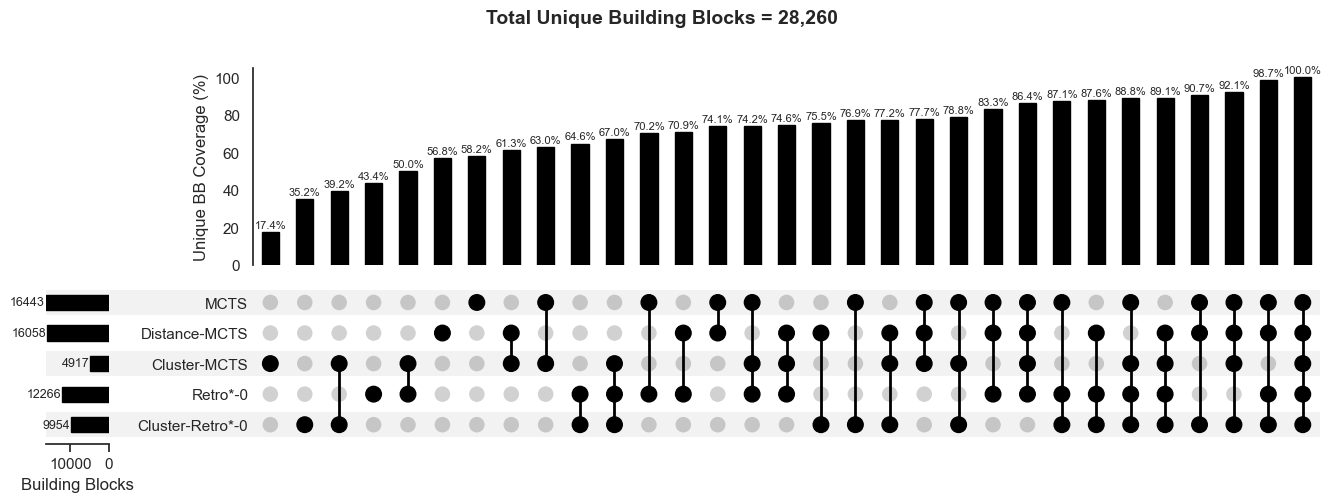

In [14]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents
import pandas as pd

# ==============================================================================
# STEP 1: Get all unique building blocks per method (across all molecules)
# ==============================================================================

print("Collecting all building blocks per method...")

all_bbs_per_method = {}

for method in methods:
    df = all_building_blocks[method]
    # Collect all unique InChI keys across all molecules for this method
    all_inchi_keys = set()
    for inchi_list in df['unique_building_blocks_inchi_keys']:
        all_inchi_keys.update(inchi_list)
    all_bbs_per_method[method] = all_inchi_keys
    print(f"{method}: {len(all_inchi_keys)} unique building blocks")

# Calculate total unique BBs across ALL methods
all_bbs_combined = set()
for bbs in all_bbs_per_method.values():
    all_bbs_combined.update(bbs)

total_unique_bbs = len(all_bbs_combined)
print(f"\nTotal unique building blocks across all methods: {total_unique_bbs}")

# ==============================================================================
# STEP 2: UpSet Plot (Union Coverage % on TOP, Absolute Counts on LEFT)
# ==============================================================================

print("\nCreating UpSet plot (Union Coverage % on Top, Absolute Counts on Left)...")

# Reverse the order for the UpSet plot (bottom to top)
upset_data = {method: all_bbs_per_method[method] for method in reversed(list(methods))}

# Create UpSet plot object
upset = UpSet(from_contents(upset_data), 
              subset_size='count',
              show_counts='%.1f%%',
              sort_by='cardinality',
              sort_categories_by='input')  # This will use the input order from upset_data

# Override the INTERSECTION SIZES (top plot) with UNION percentages
print("Calculating union coverage rates for top plot...")

original_intersections = upset.intersections.copy()
new_values = []
set_names = upset.intersections.index.names

for bool_tuple in original_intersections.index:
    participating_set_names = [set_names[i] for i, is_in in enumerate(bool_tuple) if is_in]
    
    if not participating_set_names:
        new_values.append(0)
        continue
    
    participating_sets = [upset_data[name] for name in participating_set_names]
    union_of_participants = set.union(*participating_sets)
    
    coverage_rate = (len(union_of_participants) / total_unique_bbs) * 100
    new_values.append(coverage_rate)

# Create the new Series with the union percentages
new_intersections_series = pd.Series(new_values, index=original_intersections.index)

# Sort the Series by the new percentage values (ascending)
new_intersections_series = new_intersections_series.sort_values(ascending=True)

# Assign this new, RE-SORTED data to the plot object
upset.intersections = new_intersections_series

fig = plt.figure(figsize=(16, 8))

# Plot the modified UpSet object
axes_dict = upset.plot(fig=fig)

# Remove grid lines
print("Removing grid lines...")
axes_dict['intersections'].grid(False)
axes_dict['totals'].grid(False)

# Remove x-axis ticks on the totals (left) plot
print("Removing x-axis ticks on absolute counts...")
axes_dict['totals'].tick_params(axis='x', which='both', top=False, bottom=True, labelbottom=True)

# Make the text labels on top of the bars smaller
print("Resizing top plot labels...")
for text in axes_dict['intersections'].texts:
    text.set_fontsize(8)

# Fix left-plot (totals) labels, size, and position
print("Re-formatting and adjusting left plot (totals) labels...")
offset = axes_dict['totals'].get_xlim()[1] * 0.03
    
for text in axes_dict['totals'].texts:
    try:
        current_label = text.get_text()
        if '%' in current_label:
            value = float(current_label.replace('%', ''))
            new_label = f'{int(value)}'
            text.set_text(new_label)
            text.set_fontsize(9)
            
            x_pos, y_pos = text.get_position()
            text.set_position((x_pos + offset, y_pos))
            
    except ValueError:
        # print ValueError and continue
        print(f"ValueError encountered with label: {current_label}")
        pass

# Update axis labels
axes_dict['intersections'].set_ylabel('Unique BB Coverage (%)')
axes_dict['totals'].set_xlabel('Building Blocks')

# Update title
plt.suptitle(f'Total Unique Building Blocks = {total_unique_bbs:,}', 
             fontsize=14, fontweight='bold', y=1.0)

plot_filename = f"{save_path}/3_100_chembl_building_blocks_upset_plot_union_coverage_top_percent.pdf"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

print(f"\nPlot saved to {plot_filename}")
plt.show()

### Get the removed building block results


If the comparison between the old search problem and the new search problem is large, that means that we need to research if the underlying building blocks change as the problem changes

we can also do a comparison of how much of the unique bb are covered by the removed bb but i would not do that

In [15]:
import os
from pathlib import Path
import pandas as pd

def find_algorithm_removed_building_blocks(key):
    """Map removed BB experiment file paths/names to algorithm names"""
    # Convert to string and lowercase for easier matching
    key_lower = str(key).lower()
    
    # Removed BB experiment naming (from HDF files)
    # Pattern: {number}_dpvn_ssm_chembl_{algorithm}_...
    if "0_dpvn_ssm_chembl_retrostar_0" in key_lower:
        return "Retro*-0"
    elif "1_dpvn_ssm_chembl_default_mcts" in key_lower:
        return "MCTS"
    elif "2_dpvn_ssm_chembl_mcts_diversity_forcing" in key_lower:
        return "Distance-MCTS"
    elif "6_dpvn_ssm_chembl_expansion_cluster_mcts" in key_lower:
        return "Cluster-MCTS"
    elif "5_dpvn_ssm_chembl_retrostar_0_clustered" in key_lower:
        return "Cluster-Retro*-0"
    else:
        raise ValueError(f"Could not map removed BB experiment file {key} to an algorithm")

def load_removed_bb_results(removed_bb_path, chembl100_targets, find_algorithm_func):
    """
    Load all .hdf files from removed BB directory, filter by chembl in name,
    and keep only the chembl100 molecules.
    
    Args:
        removed_bb_path: Path to directory with .hdf files
        chembl100_targets: Set/list of SMILES from chembl100
        find_algorithm_func: Function to map filename to algorithm name
    
    Returns:
        dict: {algorithm_name: DataFrame with solved_rate}
    """
    removed_bb_path = Path(removed_bb_path)
    chembl100_targets_set = set(chembl100_targets)
    
    results = {}
    
    # Find all .hdf files with 'chembl' in the name
    hdf_files = [f for f in removed_bb_path.glob("*.hdf") if 'chembl' in f.name.lower()]
    
    print(f"Found {len(hdf_files)} chembl HDF files in {removed_bb_path}")
    
    for hdf_file in hdf_files:
        print(f"\nProcessing: {hdf_file.name}")
        
        # Get algorithm name - USE THE PASSED FUNCTION PARAMETER
        algorithm = find_algorithm_func(str(hdf_file))  # Changed from find_algorithm to find_algorithm_func
        
        if algorithm is None:
            print(f"  Warning: Could not map {hdf_file.name} to an algorithm")
            continue
        
        # Load HDF file using pandas with key="table"
        df = pd.read_hdf(hdf_file, key='table')
        
        # Filter to only chembl100 molecules
        df_filtered = df[df['target'].isin(chembl100_targets_set)].copy()
        
        # Assert that we have exactly the chembl100 molecules
        assert len(df_filtered) == len(chembl100_targets_set), \
            f"{algorithm}: Expected {len(chembl100_targets_set)} molecules, got {len(df_filtered)}"
        
        # Check if all chembl100 targets are present
        missing_targets = chembl100_targets_set - set(df_filtered['target'])
        if missing_targets:
            raise ValueError(f"{algorithm}: Missing {len(missing_targets)} chembl100 targets")
        
        # Calculate solved rate
        solved_rate = (df_filtered['is_solved'].sum() / len(df_filtered)) * 100
        
        results[algorithm] = {
            'dataframe': df_filtered,
            'solved_rate': solved_rate,
            'num_solved': df_filtered['is_solved'].sum(),
            'total': len(df_filtered)
        }
        
        print(f"  Algorithm: {algorithm}")
        print(f"  Molecules: {len(df_filtered)}")
        print(f"  Solved: {df_filtered['is_solved'].sum()} ({solved_rate:.2f}%)")
    
    return results

removed_building_block_results = str(repository_directory) +   "/data/results/azf/removed_best_first_building_blocks/"

# Load removed BB results
print("Loading removed building block experiment results...")
chembl100_targets = all_building_blocks[list(all_building_blocks.keys())[0]]['target']
removed_bb_results = load_removed_bb_results(
    removed_building_block_results, 
    chembl100_targets, 
    find_algorithm_removed_building_blocks
)

# show the an example of loaded data for the first algorithm
first_algorithm = list(removed_bb_results.keys())[0]
print(f"\nExample data for {first_algorithm}:")
print("\nDataFrame columns:" + removed_bb_results[first_algorithm]['dataframe'].columns)
removed_bb_results[first_algorithm]['dataframe']

Loading removed building block experiment results...
Found 5 chembl HDF files in /Users/alankaihassen/development/diversity_search_rebuttal/updated_code/SPRS/data/results/azf/removed_best_first_building_blocks

Processing: 0_dpvn_ssm_chembl_retrostar_0_policy_uspto_template_based_stock_emolecules_without_retrostar_depth_30_25000_iterations.hdf
  Algorithm: Retro*-0
  Molecules: 100
  Solved: 93 (93.00%)

Processing: 5_dpvn_ssm_chembl_retrostar_0_clustered_first_occurence_policy_uspto_template_based_stock_emolecules_without_retrostar_0_depth_30_25000_iterations.hdf
  Algorithm: Cluster-Retro*-0
  Molecules: 100
  Solved: 57 (57.00%)

Processing: 1_dpvn_ssm_chembl_DEFAULT_mcts_50_wide_policy_uspto_template_based_stock_emolecules_without_retrostar_depth_30.hdf
  Algorithm: MCTS
  Molecules: 100
  Solved: 71 (71.00%)

Processing: 6_dpvn_ssm_chembl_expansion_cluster_mcts_first_occurence_policy_uspto_template_based_stock_emolecules_without_retrostar_0_depth_30.hdf
  Algorithm: Cluster-MCTS
 

,index,target,search_time,first_solution_time,first_solution_iteration,number_of_nodes,max_transforms,max_children,number_of_routes,number_of_solved_routes,...,number_of_precursors,number_of_precursors_in_stock,precursors_in_stock,precursors_not_in_stock,precursors_availability,policy_used_counts,profiling,stock_info,top_scores,trees
3,3,O=C1c2cc(OCCC3CCN(Cc4ccc(C5=NCCN5)cc4)CC3)ccc2...,20.537904,20.537837,73,2822,6,51,4733,100,...,6,6,"COc1ccc(C)cc1, c1ccccc1, N#Cc1ccc(C=O)cc1, CC(...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 25210},"{'expansion_calls': 73, 'reactants_generations...",{'COc1ccc(C)cc1': ['emolecules_without_retrost...,"0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750...","[{'type': 'mol', 'hide': False, 'smiles': 'O=C..."
27,27,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCCCCN(O)C...,28.049953,28.049871,142,3740,7,44,9042,4,...,4,4,"COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC(C)=O, OCC...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 54307},"{'expansion_calls': 142, 'reactants_generation...",{'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC(C)=O': ...,"0.9866, 0.9866, 0.9866, 0.9866","[{'type': 'mol', 'hide': False, 'smiles': 'COc..."
35,35,COc1cc2c(Oc3ccc(NC(=O)c4nc5ccccc5n(-c5ccccc5Cl...,35.144963,35.144891,162,5073,9,44,13047,12,...,7,7,"OCCCN1CCCC1, COc1cc2c(O)ccnc2cc1OCc1ccccc1, Nc...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 76729},"{'expansion_calls': 162, 'reactants_generation...",{'OCCCN1CCCC1': ['emolecules_without_retrostar...,"0.9560, 0.9560, 0.9560, 0.9560, 0.9560, 0.9560...","[{'type': 'mol', 'hide': False, 'smiles': 'COc..."
47,47,CNC(=O)c1ccccc1Nc1cc(Nc2ccc(N3CCOCC3)cc2)ncc1C...,5.548847,5.548772,3,152,2,38,837,68,...,3,3,"CNC(=O)c1ccccc1I, Nc1cc(Cl)ncc1C(F)(F)F, CC(=O...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 2451},"{'expansion_calls': 3, 'reactants_generations'...",{'CNC(=O)c1ccccc1I': ['emolecules_without_retr...,"0.9940, 0.9940, 0.9940, 0.9940, 0.9940, 0.9940...","[{'type': 'mol', 'hide': False, 'smiles': 'CNC..."
54,54,O=C(NCc1cccc(-c2cccc(-c3cc4c[nH]ccc-4n3)c2O)c1...,100.349068,100.348996,332,12704,8,59,5588,5,...,4,4,"CCN(CC)C(=O)Nc1ccc(C(=O)OC)cc1, COc1c(Br)cccc1...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 22119},"{'expansion_calls': 332, 'reactants_generation...",{'CCN(CC)C(=O)Nc1ccc(C(=O)OC)cc1': ['emolecule...,"0.9560, 0.9560, 0.9560, 0.9560, 0.9560","[{'type': 'mol', 'hide': False, 'smiles': 'O=C..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,977,CCOc1cc(N2CCC(N3CCN(CC(F)F)CC3)CC2)ccc1Nc1nccc...,55.541043,55.540979,284,9265,10,84,24523,2,...,7,7,"CCOc1cc(F)ccc1[N+](=O)[O-], O=C(Nc1ccccn1)OCc1...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 155685},"{'expansion_calls': 284, 'reactants_generation...",{'CCOc1cc(F)ccc1[N+](=O)[O-]': ['emolecules_wi...,"0.9560, 0.9560, 0.8504, 0.8504, 0.8504, 0.8504...","[{'type': 'mol', 'hide': False, 'smiles': 'CCO..."
978,978,O=C(NCCCCN1CCC(c2cccc3ccccc23)CC1)c1ccc(-c2ccc...,4.579206,4.579140,3,150,2,49,920,2,...,3,3,"NCCCC(=O)N1CCC(c2cccc3ccccc23)CC1, CC1(C)OB(c2...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 2706},"{'expansion_calls': 3, 'reactants_generations'...",{'NCCCC(=O)N1CCC(c2cccc3ccccc23)CC1': ['emolec...,"0.9940, 0.9940, 0.7565, 0.7565, 0.7565, 0.7565...","[{'type': 'mol', 'hide': False, 'smiles': 'O=C..."
982,982,CNCCON=C(C)CN1CCN(C(=O)c2cc(C(F)(F)F)cc(C(F)(F...,40.589559,40.589492,117,4067,6,58,827,25,...,6,6,"COC(=O)c1cc(C(F)(F)F)cc(C(F)(F)F)c1, CCOC(=O)N...",,emolecules_without_retrostar_0;emolecules_with...,{'retrostar_mlp': 6171},"{'expansion_calls': 117, 'reactants_generation...",{'COC(=O)c1cc(C(F)(F)F)cc(C(F)(F)F)c1': ['emol...,"0.9634, 0.9634, 0.9634, 0.9634, 0.9634, 0.9634...","[{'type': 'mol', 'hide': False, 'smiles': 'CNC..."
988,988,Cc1ccc(-c2nn(-c3ccccc3)cc2-c2nc3ccccc3n2S(=O)(...,44.910639,44.910556,150,4240,7,61,101

In [16]:
# Create a summary DataFrame
summary_data = []
for algorithm, data in removed_bb_results.items():
    summary_data.append({
        'algorithm': algorithm,
        'solved_rate': data['solved_rate'],
        'num_solved': data['num_solved'],
        'total_molecules': data['total']
    })

removed_bb_summary_df = pd.DataFrame(summary_data)
removed_bb_summary_df = removed_bb_summary_df.sort_values('algorithm')

print("\n" + "="*80)
print("REMOVED BB EXPERIMENT SUMMARY")
print("="*80)
print(removed_bb_summary_df)

# Match solved rates to methods for plotting
removed_bb_solved_rates = {}
for method in methods:
    if method in removed_bb_results:
        removed_bb_solved_rates[method] = removed_bb_results[method]['solved_rate']
    else:
        print(f"Warning: No removed BB result found for {method}")
        removed_bb_solved_rates[method] = 0.0

print("\n" + "="*80)
print("MATCHED SOLVED RATES")
print("="*80)
for method in methods:
    print(f"{method}: {removed_bb_solved_rates[method]:.2f}%")


REMOVED BB EXPERIMENT SUMMARY
          algorithm  solved_rate  num_solved  total_molecules
3      Cluster-MCTS         49.0          49              100
1  Cluster-Retro*-0         57.0          57              100
4     Distance-MCTS         70.0          70              100
2              MCTS         71.0          71              100
0          Retro*-0         93.0          93              100

MATCHED SOLVED RATES
MCTS: 71.00%
Distance-MCTS: 70.00%
Cluster-MCTS: 49.00%
Retro*-0: 93.00%
Cluster-Retro*-0: 57.00%


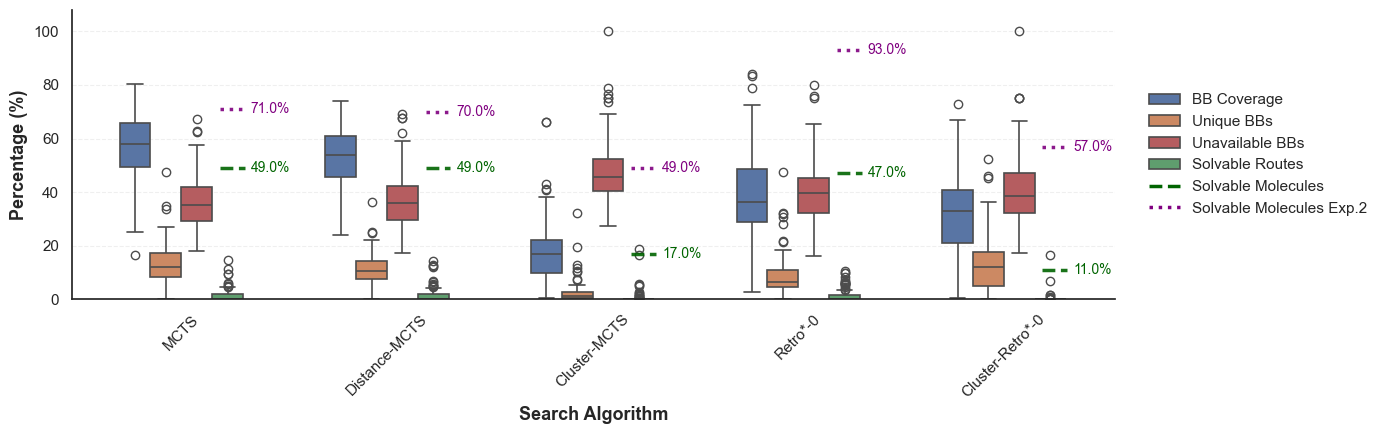


COMPREHENSIVE SUMMARY TABLE
Method               Coverage     Unique Rate  Unavailable  Solvable Rt  Solvable Mol Experiment  
--------------------------------------------------------------------------------
MCTS                  56.94%       13.41%       36.22%         1.36%         49.00%          71.00%
Distance-MCTS         53.02%       11.34%       37.02%         1.49%         49.00%          70.00%
Cluster-MCTS          17.85%        2.34%       47.47%         0.64%         17.00%          49.00%
Retro*-0              39.19%        8.74%       39.79%         1.37%         47.00%          93.00%
Cluster-Retro*-0      31.40%       13.07%       40.39%         0.28%         11.00%          57.00%


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Set Seaborn style
sns.set(style="white")

# Get methods and prepare data
methods = all_building_blocks.keys()
short_methods = all_building_blocks.keys()
n_methods = len(methods)

# Prepare combined data for seaborn grouped boxplot
plot_data = []

for method, short_name in zip(methods, short_methods):
    # Add coverage data
    for value in coverage_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'BB Coverage',
            'value': value
        })
    
    # Add unique rate data
    for value in unique_rate_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unique BBs',
            'value': value
        })
    
    # Add percentage of unsolved building blocks
    df = all_building_blocks[method]
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
        else:
            unsolved_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unavailable BBs',
            'value': unsolved_pct
        })
    
    # Add percentage of SOLVED routes
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
        else:
            solved_routes_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Solvable Routes',
            'value': solved_routes_pct
        })

df_plot = pd.DataFrame(plot_data)

# Define algorithm order (use short names)
algorithm_order = list(short_methods)

# Define color palette for the four metrics
palette = {
    'BB Coverage': '#4C72B0',
    'Unique BBs': '#DD8452',
    'Unavailable BBs': '#C44E52',
    'Solvable Routes': '#55A868'
}

# Calculate overall molecule solved rate per algorithm (with emolecules stock)
overall_solved_rates = {}
for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    total_molecules = len(df)
    solved_molecules = df['bb_molecule_solved'].sum()
    overall_solved_rates[short_name] = (solved_molecules / total_molecules * 100) if total_molecules > 0 else 0

# Get removed BB solved rates (from the loaded removed BB experiment results)
removed_bb_overall_solved_rates = {}
for method in methods:
    if method in removed_bb_solved_rates:
        removed_bb_overall_solved_rates[method] = removed_bb_solved_rates[method]
    else:
        removed_bb_overall_solved_rates[method] = 0.0

# Create single plot with grouped boxes
fig, ax = plt.subplots(1, 1, figsize=(14, 4.5))

# Grouped box plot with all 4 metrics - SMALLER width
bp = sns.boxplot(data=df_plot, x="algorithm", y="value", hue="Metric", ax=ax,
                 palette=palette, order=algorithm_order, linewidth=1.2, width=0.6)

ax.set_ylabel("Percentage (%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Search Algorithm", fontsize=13, fontweight='bold')
ax.set_ylim(0, 108)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Add horizontal lines for overall solved rate at the Solved Route Rate boxes
# Each algorithm has 4 box groups (4 metrics), we want the 4th one (Solved Route Rate)
n_metrics = 4
box_width = 0.6 / n_metrics  # Total width divided by number of metrics

for i, algo in enumerate(algorithm_order):
    overall_rate = overall_solved_rates[algo]
    removed_bb_rate = removed_bb_overall_solved_rates[algo]
    
    # Calculate the x-position of the Solved Route Rate box (index 3, 0-indexed)
    # The boxes are centered at integer positions (0, 1, 2, ...)
    # Within each position, boxes are offset from center
    offset = (3 - (n_metrics - 1) / 2) * box_width * 1.1  # 1.1 accounts for spacing
    x_center = i + offset
    
    # Draw horizontal line at the overall solved rate (with emolecules stock)
    line_width = box_width * 0.8
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [overall_rate, overall_rate],
            color='darkgreen', linewidth=2.5, linestyle='--', zorder=10, alpha=0.9)
    
    # Add text label next to the line - clean text with %
    ax.text(x_center + line_width/2 + 0.03, overall_rate, 
            f'{overall_rate:.1f}%',
            va='center', ha='left', fontsize=10, color='darkgreen')
    
    # Draw horizontal line at the removed BB solved rate (without removed BBs)
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [removed_bb_rate, removed_bb_rate],
            color='purple', linewidth=2.5, linestyle=':', zorder=10, alpha=0.9)
    
    # Add text label next to the line - clean text with %
    ax.text(x_center + line_width/2 + 0.03, removed_bb_rate, 
            f'{removed_bb_rate:.1f}%',
            va='center', ha='left', fontsize=10, color='purple')

# Add legend entry for the overall solved rate lines
legend_elements = ax.get_legend_handles_labels()
legend_elements[0].append(Line2D([0], [0], color='darkgreen', linewidth=2.5, 
                                 linestyle='--', label='Solvable Molecules'))
legend_elements[0].append(Line2D([0], [0], color='purple', linewidth=2.5, 
                                 linestyle=':', label='Solvable Molecules Exp.2'))
ax.legend(handles=legend_elements[0], 
          labels=legend_elements[1] + ['Solvable Molecules', 'Solvable Molecules Exp.2'],
          fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# Despine and show
sns.despine()
plt.tight_layout()
plt.savefig(f"{save_path}/building_blocks_comprehensive_boxplot.pdf", 
            bbox_inches='tight', dpi=300)
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print(f"{'Method':<20} {'Coverage':<12} {'Unique Rate':<12} {'Unavailable':<12} {'Solvable Rt':<12} {'Solvable Mol':<12} {'Experiment':<12}")
print("-" * 80)

for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    cov_mean = np.mean(coverage_data[method])
    uniq_mean = np.mean(unique_rate_data[method])
    
    # Calculate unsolved BB rate per molecule
    unsolved_bb_rates = []
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
            unsolved_bb_rates.append(unsolved_pct)
    
    unsolved_bb_mean = np.mean(unsolved_bb_rates) if unsolved_bb_rates else 0
    
    # Calculate SOLVED route rate per molecule
    solved_route_rates = []
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
            solved_route_rates.append(solved_routes_pct)
    
    solved_route_mean = np.mean(solved_route_rates) if solved_route_rates else 0
    overall_solved = overall_solved_rates[short_name]
    removed_bb_exp_solved = removed_bb_overall_solved_rates[short_name]
    
    print(f"{short_name:<20} {cov_mean:>6.2f}%      {uniq_mean:>6.2f}%      "
          f"{unsolved_bb_mean:>6.2f}%       {solved_route_mean:>6.2f}%        "
          f"{overall_solved:>6.2f}%         {removed_bb_exp_solved:>6.2f}%")

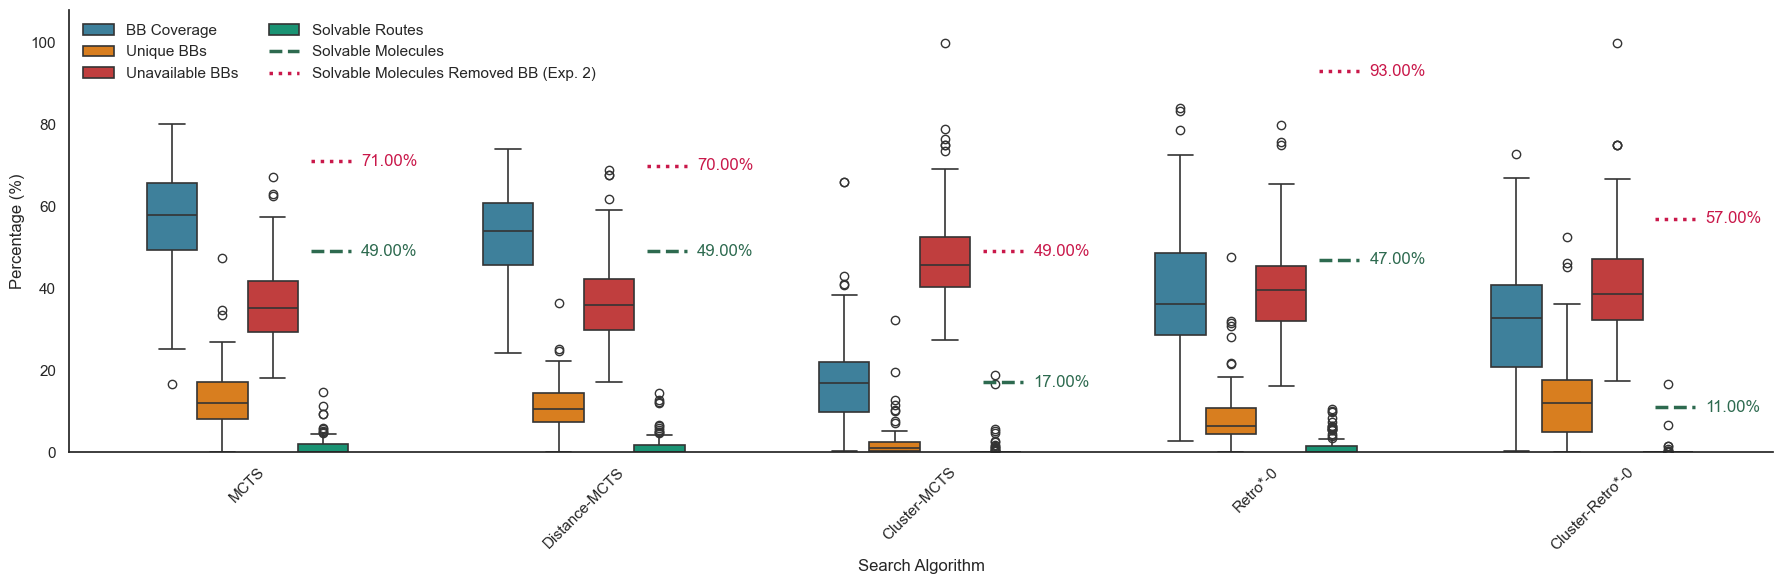


COMPREHENSIVE SUMMARY TABLE
Method               Coverage     Unique Rate  Unavailable  Solvable Rt  Solvable Mol Experiment  
--------------------------------------------------------------------------------
MCTS                  56.94%       13.41%       36.22%         1.36%         49.00%          71.00%
Distance-MCTS         53.02%       11.34%       37.02%         1.49%         49.00%          70.00%
Cluster-MCTS          17.85%        2.34%       47.47%         0.64%         17.00%          49.00%
Retro*-0              39.19%        8.74%       39.79%         1.37%         47.00%          93.00%
Cluster-Retro*-0      31.40%       13.07%       40.39%         0.28%         11.00%          57.00%


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Set Seaborn style
sns.set(style="white")

# Get methods and prepare data
methods = all_building_blocks.keys()
short_methods = all_building_blocks.keys()
n_methods = len(methods)

# Define algorithm order
algorithm_order = [
    'MCTS',
    'Distance-MCTS',
    'Cluster-MCTS',
    'Retro*-0',
    'Cluster-Retro*-0'
]

# Define a color palette
palette = sns.color_palette("bright", len(algorithm_order))

# Prepare combined data for seaborn grouped boxplot
plot_data = []

for method, short_name in zip(methods, short_methods):
    # Add coverage data
    for value in coverage_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'BB Coverage',
            'value': value
        })
    
    # Add unique rate data
    for value in unique_rate_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unique BBs',
            'value': value
        })
    
    # Add percentage of unsolved building blocks
    df = all_building_blocks[method]
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
        else:
            unsolved_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unavailable BBs',
            'value': unsolved_pct
        })
    
    # Add percentage of SOLVED routes
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
        else:
            solved_routes_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Solvable Routes',
            'value': solved_routes_pct
        })

df_plot = pd.DataFrame(plot_data)

# Define color palette for the four metrics
metric_palette = {
    'BB Coverage': '#2E86AB',      # Professional blue
    'Unique BBs': '#F77F00',       # Warm orange
    'Unavailable BBs': '#D62828',   # Clear red
    'Solvable Routes': '#06A77D'    # Fresh green
}

molecules_solved_color = "#2D6A4F"           # Forest green (darker than Solvable Routes)
molecules_experiment_solved_color = "#C9184A"  # Deep magenta

# Calculate overall molecule solved rate per algorithm (with emolecules stock)
overall_solved_rates = {}
for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    total_molecules = len(df)
    solved_molecules = df['bb_molecule_solved'].sum()
    overall_solved_rates[short_name] = (solved_molecules / total_molecules * 100) if total_molecules > 0 else 0

# Get removed BB solved rates (from the loaded removed BB experiment results)
removed_bb_overall_solved_rates = {}
for method in methods:
    if method in removed_bb_solved_rates:
        removed_bb_overall_solved_rates[method] = removed_bb_solved_rates[method]
    else:
        removed_bb_overall_solved_rates[method] = 0.0

# Create single plot with grouped boxes
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

# Grouped box plot with all 4 metrics
bp = sns.boxplot(data=df_plot, x="algorithm", y="value", hue="Metric", ax=ax,
                 palette=metric_palette, order=algorithm_order, linewidth=1.2, width=0.6)

ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Search Algorithm")
ax.set_ylim(0, 108)
ax.tick_params(axis='x', rotation=45)

# Add horizontal lines for overall solved rate at the Solved Route Rate boxes
# Each algorithm has 4 box groups (4 metrics), we want the 4th one (Solved Route Rate)
n_metrics = 4
box_width = 0.6 / n_metrics  # Total width divided by number of metrics

for i, algo in enumerate(algorithm_order):
    overall_rate = overall_solved_rates[algo]
    removed_bb_rate = removed_bb_overall_solved_rates[algo]
    
    # Calculate the x-position of the Solved Route Rate box (index 3, 0-indexed)
    # The boxes are centered at integer positions (0, 1, 2, ...)
    # Within each position, boxes are offset from center
    offset = (3 - (n_metrics - 1) / 2) * box_width * 1.1  # 1.1 accounts for spacing
    x_center = i + offset
    
    # Draw horizontal line at the overall solved rate (with emolecules stock)
    line_width = box_width * 0.8
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [overall_rate, overall_rate],
            color=molecules_solved_color, linewidth=2.5, linestyle='--', zorder=10, alpha=1)
    
    # Add text label next to the line - clean text with %
    ax.text(x_center + line_width/2 + 0.03, overall_rate, 
            f'{overall_rate:.2f}%',
            va='center', ha='left', fontsize=12, color=molecules_solved_color)
    
    # Draw horizontal line at the removed BB solved rate (without removed BBs)
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [removed_bb_rate, removed_bb_rate],
            color=molecules_experiment_solved_color, linewidth=2.5, linestyle=':', zorder=10, alpha=1)
    
    # Add text label next to the line - clean text with %
    ax.text(x_center + line_width/2 + 0.03, removed_bb_rate, 
            f'{removed_bb_rate:.2f}%',
            va='center', ha='left', fontsize=12, color=molecules_experiment_solved_color)

# Add legend entry for the overall solved rate lines
legend_elements = ax.get_legend_handles_labels()
legend_elements[0].append(Line2D([0], [0], color=molecules_solved_color, linewidth=2.5, 
                                 linestyle='--', label='Solvable Molecules'))
legend_elements[0].append(Line2D([0], [0], color=molecules_experiment_solved_color, linewidth=2.5, 
                                 linestyle=':', label='Solvable Molecules Exp.2'))
ax.legend(handles=legend_elements[0], 
          labels=legend_elements[1] + ['Solvable Molecules', 'Solvable Molecules Removed BB (Exp. 2)'],
          loc='upper left', ncol=2, frameon=False)

# Despine and show
sns.despine()
plt.tight_layout()
plt.savefig(f"{save_path}/3_100_chembl_building_blocks_comprehensive_boxplot.pdf", 
            bbox_inches='tight', dpi=300)
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print(f"{'Method':<20} {'Coverage':<12} {'Unique Rate':<12} {'Unavailable':<12} {'Solvable Rt':<12} {'Solvable Mol':<12} {'Experiment':<12}")
print("-" * 80)

for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    cov_mean = np.mean(coverage_data[method])
    uniq_mean = np.mean(unique_rate_data[method])
    
    # Calculate unsolved BB rate per molecule
    unsolved_bb_rates = []
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
            unsolved_bb_rates.append(unsolved_pct)
    
    unsolved_bb_mean = np.mean(unsolved_bb_rates) if unsolved_bb_rates else 0
    
    # Calculate SOLVED route rate per molecule
    solved_route_rates = []
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
            solved_route_rates.append(solved_routes_pct)
    
    solved_route_mean = np.mean(solved_route_rates) if solved_route_rates else 0
    overall_solved = overall_solved_rates[short_name]
    removed_bb_exp_solved = removed_bb_overall_solved_rates[short_name]
    
    print(f"{short_name:<20} {cov_mean:>6.2f}%      {uniq_mean:>6.2f}%      "
          f"{unsolved_bb_mean:>6.2f}%       {solved_route_mean:>6.2f}%        "
          f"{overall_solved:>6.2f}%         {removed_bb_exp_solved:>6.2f}%")

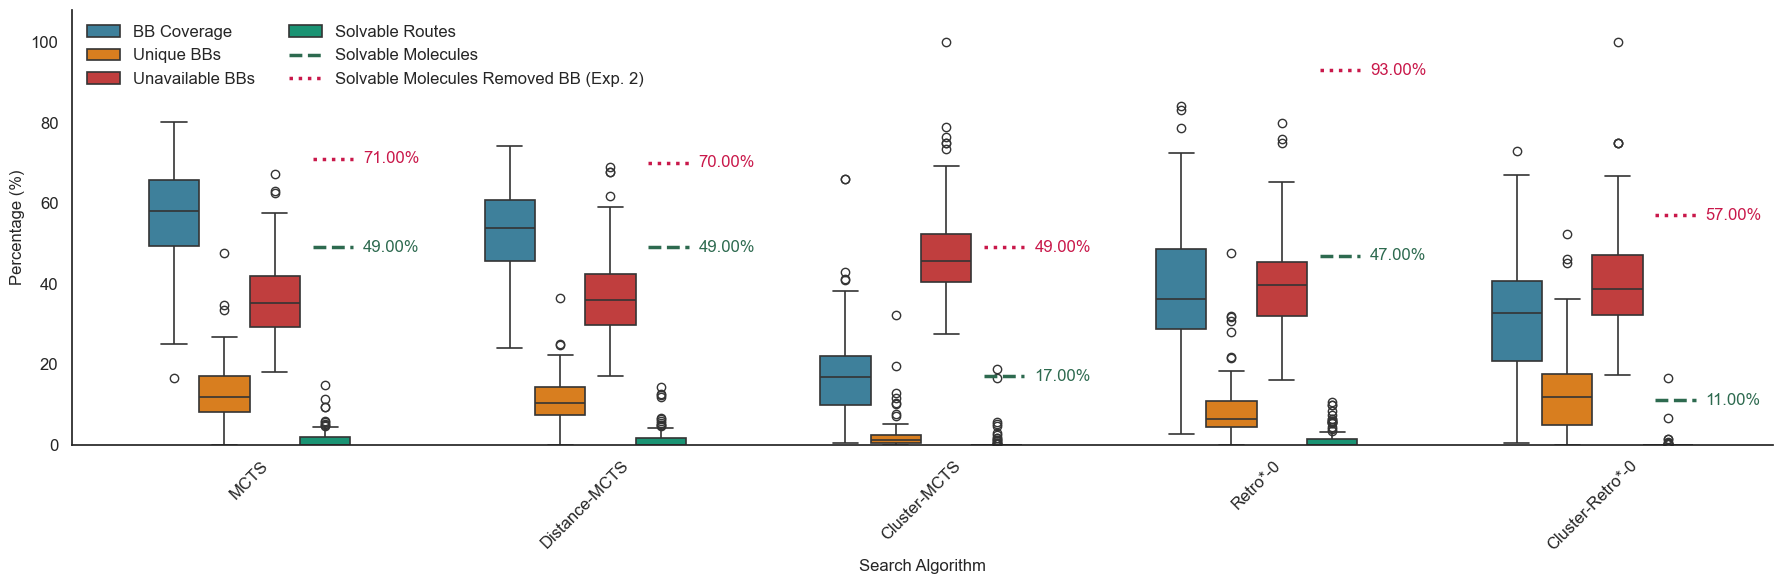


COMPREHENSIVE SUMMARY TABLE
Method               Coverage     Unique Rate  Unavailable  Solvable Rt  Solvable Mol Experiment  
--------------------------------------------------------------------------------
MCTS                  56.94%       13.41%       36.22%         1.36%         49.00%          71.00%
Distance-MCTS         53.02%       11.34%       37.02%         1.49%         49.00%          70.00%
Cluster-MCTS          17.85%        2.34%       47.47%         0.64%         17.00%          49.00%
Retro*-0              39.19%        8.74%       39.79%         1.37%         47.00%          93.00%
Cluster-Retro*-0      31.40%       13.07%       40.39%         0.28%         11.00%          57.00%


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Set Seaborn style
sns.set(style="white")

# Get methods and prepare data
methods = all_building_blocks.keys()
short_methods = all_building_blocks.keys()
n_methods = len(methods)

# Define algorithm order
algorithm_order = [
    'MCTS',
    'Distance-MCTS',
    'Cluster-MCTS',
    'Retro*-0',
    'Cluster-Retro*-0'
]

# Define a color palette
palette = sns.color_palette("bright", len(algorithm_order))

# Prepare combined data for seaborn grouped boxplot
plot_data = []

for method, short_name in zip(methods, short_methods):
    # Add coverage data
    for value in coverage_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'BB Coverage',
            'value': value
        })
    
    # Add unique rate data
    for value in unique_rate_data[method]:
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unique BBs',
            'value': value
        })
    
    # Add percentage of unsolved building blocks
    df = all_building_blocks[method]
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
        else:
            unsolved_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Unavailable BBs',
            'value': unsolved_pct
        })
    
    # Add percentage of SOLVED routes
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
        else:
            solved_routes_pct = 0
        
        plot_data.append({
            'algorithm': short_name,
            'Metric': 'Solvable Routes',
            'value': solved_routes_pct
        })

df_plot = pd.DataFrame(plot_data)

# Define color palette for the four metrics
metric_palette = {
    'BB Coverage': '#2E86AB',      # Professional blue
    'Unique BBs': '#F77F00',       # Warm orange
    'Unavailable BBs': '#D62828',   # Clear red
    'Solvable Routes': '#06A77D'    # Fresh green
}

molecules_solved_color = "#2D6A4F"           # Forest green (darker than Solvable Routes)
molecules_experiment_solved_color = "#C9184A"  # Deep magenta

# Calculate overall molecule solved rate per algorithm (with emolecules stock)
overall_solved_rates = {}
for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    total_molecules = len(df)
    solved_molecules = df['bb_molecule_solved'].sum()
    overall_solved_rates[short_name] = (solved_molecules / total_molecules * 100) if total_molecules > 0 else 0

# Get removed BB solved rates (from the loaded removed BB experiment results)
removed_bb_overall_solved_rates = {}
for method in methods:
    if method in removed_bb_solved_rates:
        removed_bb_overall_solved_rates[method] = removed_bb_solved_rates[method]
    else:
        removed_bb_overall_solved_rates[method] = 0.0

# Create single plot with grouped boxes
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

# Grouped box plot with all 4 metrics
bp = sns.boxplot(data=df_plot, x="algorithm", y="value", hue="Metric", ax=ax,
                 palette=metric_palette, order=algorithm_order, linewidth=1.2, width=0.6)

ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_xlabel("Search Algorithm", fontsize=12)
ax.set_ylim(0, 108)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Add horizontal lines for overall solved rate at the Solved Route Rate boxes
# Each algorithm has 4 box groups (4 metrics), we want the 4th one (Solved Route Rate)
n_metrics = 4
box_width = 0.6 / n_metrics  # Total width divided by number of metrics

for i, algo in enumerate(algorithm_order):
    overall_rate = overall_solved_rates[algo]
    removed_bb_rate = removed_bb_overall_solved_rates[algo]
    
    # Calculate the x-position of the Solved Route Rate box (index 3, 0-indexed)
    # The boxes are centered at integer positions (0, 1, 2, ...)
    # Within each position, boxes are offset from center
    offset = (3 - (n_metrics - 1) / 2) * box_width * 1.1  # 1.1 accounts for spacing
    x_center = i + offset
    
    # Draw horizontal line at the overall solved rate (with emolecules stock)
    line_width = box_width * 0.8
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [overall_rate, overall_rate],
            color=molecules_solved_color, linewidth=2.5, linestyle='--', zorder=10, alpha=1)
    
    # Add text label next to the line - clean text with %
    ax.text(x_center + line_width/2 + 0.03, overall_rate, 
            f'{overall_rate:.2f}%',
            va='center', ha='left', fontsize=12, color=molecules_solved_color)
    
    # Draw horizontal line at the removed BB solved rate (without removed BBs)
    ax.plot([x_center - line_width/2, x_center + line_width/2], 
            [removed_bb_rate, removed_bb_rate],
            color=molecules_experiment_solved_color, linewidth=2.5, linestyle=':', zorder=10, alpha=1)
    
    # Add text label next to the line - clean text with %
    ax.text(x_center + line_width/2 + 0.03, removed_bb_rate, 
            f'{removed_bb_rate:.2f}%',
            va='center', ha='left', fontsize=12, color=molecules_experiment_solved_color)

# Add legend entry for the overall solved rate lines
legend_elements = ax.get_legend_handles_labels()
legend_elements[0].append(Line2D([0], [0], color=molecules_solved_color, linewidth=2.5, 
                                 linestyle='--', label='Solvable Molecules'))
legend_elements[0].append(Line2D([0], [0], color=molecules_experiment_solved_color, linewidth=2.5, 
                                 linestyle=':', label='Solvable Molecules Exp.2'))
ax.legend(handles=legend_elements[0], 
          labels=legend_elements[1] + ['Solvable Molecules', 'Solvable Molecules Removed BB (Exp. 2)'],
          loc='upper left', ncol=2, frameon=False, fontsize=12)

# Despine and show
sns.despine()
plt.tight_layout()
plt.savefig(f"{save_path}/3_100_chembl_building_blocks_comprehensive_boxplot_font_12.pdf", 
            bbox_inches='tight', dpi=300)
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
print(f"{'Method':<20} {'Coverage':<12} {'Unique Rate':<12} {'Unavailable':<12} {'Solvable Rt':<12} {'Solvable Mol':<12} {'Experiment':<12}")
print("-" * 80)

for method, short_name in zip(methods, short_methods):
    df = all_building_blocks[method]
    cov_mean = np.mean(coverage_data[method])
    uniq_mean = np.mean(unique_rate_data[method])
    
    # Calculate unsolved BB rate per molecule
    unsolved_bb_rates = []
    for idx, row in df.iterrows():
        if row['num_unique_building_blocks'] > 0:
            unsolved = row['num_unique_building_blocks'] - row['num_solved_unique_building_blocks']
            unsolved_pct = (unsolved / row['num_unique_building_blocks']) * 100
            unsolved_bb_rates.append(unsolved_pct)
    
    unsolved_bb_mean = np.mean(unsolved_bb_rates) if unsolved_bb_rates else 0
    
    # Calculate SOLVED route rate per molecule
    solved_route_rates = []
    for idx, row in df.iterrows():
        total_routes = row['num_solved_routes'] + row['num_unsolved_routes']
        if total_routes > 0:
            solved_routes_pct = (row['num_solved_routes'] / total_routes) * 100
            solved_route_rates.append(solved_routes_pct)
    
    solved_route_mean = np.mean(solved_route_rates) if solved_route_rates else 0
    overall_solved = overall_solved_rates[short_name]
    removed_bb_exp_solved = removed_bb_overall_solved_rates[short_name]
    
    print(f"{short_name:<20} {cov_mean:>6.2f}%      {uniq_mean:>6.2f}%      "
          f"{unsolved_bb_mean:>6.2f}%       {solved_route_mean:>6.2f}%        "
          f"{overall_solved:>6.2f}%         {removed_bb_exp_solved:>6.2f}%")

Metric Descriptions
1. Coverage BB Rate (Blue boxes)
What it measures: For each molecule, what percentage of the total possible building blocks (found by ANY algorithm) did this specific algorithm discover?

Interpretation:

High coverage = algorithm explores a large portion of the solution space
100% = algorithm found ALL building blocks that any method could find for that molecule
Low coverage = algorithm misses many building blocks that other methods found
Example: If all algorithms together found 10 unique BBs for a molecule, and MCTS found 7 of them, MCTS has 70% coverage.

2. Unique BB Rate (Orange boxes)
What it measures: For each molecule, what percentage of the total possible building blocks are ONLY found by this algorithm (and not by any other)?

Interpretation:

High unique rate = algorithm finds many building blocks that others miss
Shows the algorithm's "unique contribution" to the solution space
0% = all BBs this algorithm found were also found by at least one other algorithm
Example: If all algorithms together found 10 unique BBs, and Distance-MCTS found 3 that NO other method found, its unique rate is 30%.

3. Removed BB Rate (Red boxes)
What it measures: For each molecule, what percentage of the building blocks discovered by this algorithm are NOT available in the eMolecules stock?

Interpretation:

High removed rate = algorithm relies heavily on unavailable building blocks
Shows how many BBs would need to be removed/sourced elsewhere
0% = all building blocks are commercially available
Calculation: (num_unique_building_blocks - num_solved_unique_building_blocks) / num_unique_building_blocks * 100

4. Removed BB Solved Route Rate (Green boxes)
What it measures: For each molecule, what percentage of the routes found by this algorithm can actually be completed using ONLY building blocks available in eMolecules stock?

Interpretation:

High solved route rate = most routes are practically feasible
Shows the practical success rate when filtering by stock availability
This is calculated AFTER deduplicating routes with identical BB sets
Calculation: num_solved_routes / (num_solved_routes + num_unsolved_routes) * 100

A route is "solved" if ALL its building blocks are in eMolecules stock.

5. Removed BB Solved Molecule Rate (Dark green dashed line)
What it measures: The percentage of molecules that have AT LEAST ONE completely solvable route (where all BBs are in stock).

Interpretation:

This is the OVERALL success rate per algorithm across all molecules
Shown as a horizontal line overlay on the green boxes
Represents the "best case" where we only need one working route per molecule
Calculation: molecules_with_at_least_one_solved_route / total_molecules * 100

6. Removed BB Experiment Solved Rate (Purple dotted line)
What it measures: The percentage of molecules that were solved when the removed building blocks were ACTUALLY removed from the stock and the search algorithm was re-run.

Interpretation:

This is the empirical validation of the analytical prediction (green line)
Difference between purple and green shows if removing BBs changes search behavior
Large gaps suggest the search finds different routes when BB availability changes
Source: Loaded from separate HDF files containing re-run experiment results.

Key Comparisons
Coverage vs Unique Rate: High coverage + high unique = algorithm explores broadly AND finds novel solutions
Removed BB Rate vs Solved Route Rate: Shows the gap between "what we found" vs "what we can actually make"
Green line vs Purple line: Analytical prediction vs empirical reality - validates if BB availability changes search outcomes
Route Rate vs Molecule Rate: Route-level feasibility vs molecule-level success (only need 1 good route per molecule)